Name - Harsh Kumar
Batch - DEEP LEARNING - 4 prn no - 202301100054

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_excel("/content/ENB2012_data.xlsx")

# Display first 5 rows
print("First 5 rows:")
print(df.head())

# Check shape
print("\nShape of dataset:")
print(df.shape)


First 5 rows:
     X1     X2     X3      X4   X5  X6   X7  X8     Y1     Y2
0  0.98  514.5  294.0  110.25  7.0   2  0.0   0  15.55  21.33
1  0.98  514.5  294.0  110.25  7.0   3  0.0   0  15.55  21.33
2  0.98  514.5  294.0  110.25  7.0   4  0.0   0  15.55  21.33
3  0.98  514.5  294.0  110.25  7.0   5  0.0   0  15.55  21.33
4  0.90  563.5  318.5  122.50  7.0   2  0.0   0  20.84  28.28

Shape of dataset:
(768, 10)


In [ ]:
print("Column Names:")
print(df.columns)


Column Names:
Index(['X1', 'X2', 'X3', 'X4', 'X5', 'X6', 'X7', 'X8', 'Y1', 'Y2'], dtype='object')


In [ ]:
print(df.dtypes)


X1    float64
X2    float64
X3    float64
X4    float64
X5    float64
X6      int64
X7    float64
X8      int64
Y1    float64
Y2    float64
dtype: object


In [ ]:
# --- Rename columns from X1-X8, Y1-Y2 to descriptive feature names ---
df.columns = [
    "Relative_Compactness",
    "Surface_Area",
    "Wall_Area",
    "Roof_Area",
    "Overall_Height",
    "Orientation",
    "Glazing_Area",
    "Glazing_Area_Distribution",
    "Heating_Load",
    "Cooling_Load"
]


In [ ]:
# Verify no missing values exist in the dataset
print("Missing values per column:")
print(df.isnull().sum())


Missing values per column:
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64


In [ ]:
# Check for duplicate rows
print("Number of duplicate rows:")
print(df.duplicated().sum())


Number of duplicate rows:
0


In [ ]:
# Summary statistics:
print("Basic Statistics:")
print(df.describe())



Basic Statistics:
       Relative_Compactness  Surface_Area   Wall_Area   Roof_Area  \
count            768.000000    768.000000  768.000000  768.000000   
mean               0.764167    671.708333  318.500000  176.604167   
std                0.105777     88.086116   43.626481   45.165950   
min                0.620000    514.500000  245.000000  110.250000   
25%                0.682500    606.375000  294.000000  140.875000   
50%                0.750000    673.750000  318.500000  183.750000   
75%                0.830000    741.125000  343.000000  220.500000   
max                0.980000    808.500000  416.500000  220.500000   

       Overall_Height  Orientation  Glazing_Area  Glazing_Area_Distribution  \
count       768.00000   768.000000    768.000000                  768.00000   
mean          5.25000     3.500000      0.234375                    2.81250   
std           1.75114     1.118763      0.133221                    1.55096   
min           3.50000     2.000000      0.00

In [ ]:
# Split dataset: X = 8 input features, y = Heating Load (target)
X = df.drop(columns=["Heating_Load", "Cooling_Load"])
y = df["Heating_Load"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)


Shape of X: (768, 8)
Shape of y: (768,)


In [ ]:
# Shuffle and split data: 80% train, 20% test
import numpy as np

# Convert to numpy arrays
X_np = X.values
y_np = y.values

# Set random seed
np.random.seed(42)

# Shuffle indices
indices = np.arange(X_np.shape[0])
np.random.shuffle(indices)

# Compute split index
split_index = int(0.8 * X_np.shape[0])

# Split
train_indices = indices[:split_index]
test_indices = indices[split_index:]

X_train = X_np[train_indices]
X_test = X_np[test_indices]

y_train = y_np[train_indices]
y_test = y_np[test_indices]

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


X_train shape: (614, 8)
X_test shape: (154, 8)


In [ ]:
# Compute mean and std from training data
mean = X_train.mean(axis=0)
std = X_train.std(axis=0)

# Standardize
X_train_scaled = (X_train - mean) / std
X_test_scaled = (X_test - mean) / std

print("Mean of scaled train:")
print(X_train_scaled.mean(axis=0))

print("\nStd of scaled train:")
print(X_train_scaled.std(axis=0))


Mean of scaled train:
[-6.46496971e-15  4.47343935e-16 -6.41180919e-16  8.15489551e-17
  5.06290630e-17  4.05032504e-17 -3.84780879e-16  3.33428544e-16]

Std of scaled train:
[1. 1. 1. 1. 1. 1. 1. 1.]


In [ ]:
# Reshape target to column vector
y_train = y_train.reshape(-1, 1)
y_test = y_test.reshape(-1, 1)

print("New y_train shape:", y_train.shape)
print("New y_test shape:", y_test.shape)


New y_train shape: (614, 1)
New y_test shape: (154, 1)


In [ ]:
# Define network architecture: 8 inputs, 5 hidden neurons, 1 output
import numpy as np

input_size = 8
hidden_size = 5
output_size = 1

np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))

W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

print("W1 shape:", W1.shape)
print("W2 shape:", W2.shape)


W1 shape: (8, 5)
W2 shape: (5, 1)


In [ ]:
# Sigmoid activation
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

# Forward pass on training data
Z1 = np.dot(X_train_scaled, W1) + b1
A1 = sigmoid(Z1)

Z2 = np.dot(A1, W2) + b2
y_pred = Z2   # Linear output (regression)

print("Z1 shape:", Z1.shape)
print("A1 shape:", A1.shape)
print("y_pred shape:", y_pred.shape)


Z1 shape: (614, 5)
A1 shape: (614, 5)
y_pred shape: (614, 1)


In [ ]:
# Mean Squared Error
loss = np.mean((y_train - y_pred) ** 2)

print("Initial Loss:", loss)


Initial Loss: 619.9825103784381


In [ ]:
# Number of training samples
n = y_train.shape[0]

# Gradient at output layer
dZ2 = (y_pred - y_train) / n

print("dZ2 shape:", dZ2.shape)


dZ2 shape: (614, 1)


In [ ]:
# Gradients for W2 and b2
dW2 = np.dot(A1.T, dZ2)
db2 = np.sum(dZ2, axis=0, keepdims=True)

print("dW2 shape:", dW2.shape)
print("db2 shape:", db2.shape)


dW2 shape: (5, 1)
db2 shape: (1, 1)


In [ ]:
# Backprop to hidden layer
dA1 = np.dot(dZ2, W2.T)

dZ1 = dA1 * (A1 * (1 - A1))

print("dZ1 shape:", dZ1.shape)


dZ1 shape: (614, 5)


In [ ]:
# Gradients for first layer
dW1 = np.dot(X_train_scaled.T, dZ1)
db1 = np.sum(dZ1, axis=0, keepdims=True)

print("dW1 shape:", dW1.shape)
print("db1 shape:", db1.shape)


dW1 shape: (8, 5)
db1 shape: (1, 5)


In [ ]:
learning_rate = 0.01

# Update output layer
W2 -= learning_rate * dW2
b2 -= learning_rate * db2

# Update hidden layer
W1 -= learning_rate * dW1
b1 -= learning_rate * db1

print("Weights updated successfully.")


Weights updated successfully.


In [ ]:
# Forward pass again after weight update
Z1_new = np.dot(X_train_scaled, W1) + b1
A1_new = 1 / (1 + np.exp(-Z1_new))

Z2_new = np.dot(A1_new, W2) + b2
y_pred_new = Z2_new

# Compute new loss
new_loss = np.mean((y_train - y_pred_new) ** 2)

print("Old Loss:", loss)
print("New Loss:", new_loss)


Old Loss: 619.9825103784381
New Loss: 596.958596902691


In [ ]:
# Reinitialize weights (important for clean training)
np.random.seed(42)

W1 = np.random.randn(input_size, hidden_size) * 0.1
b1 = np.zeros((1, hidden_size))
W2 = np.random.randn(hidden_size, output_size) * 0.1
b2 = np.zeros((1, output_size))

learning_rate = 0.1
epochs = 100

loss_history = []

for epoch in range(epochs):

    # Forward pass
    Z1 = np.dot(X_train_scaled, W1) + b1
    A1 = 1 / (1 + np.exp(-Z1))

    Z2 = np.dot(A1, W2) + b2
    y_pred = Z2

    # Loss
    loss = np.mean((y_train - y_pred) ** 2)
    loss_history.append(loss)

    # Backprop
    n = y_train.shape[0]
    dZ2 = (y_pred - y_train) / n
    dW2 = np.dot(A1.T, dZ2)
    db2 = np.sum(dZ2, axis=0, keepdims=True)

    dA1 = np.dot(dZ2, W2.T)
    dZ1 = dA1 * (A1 * (1 - A1))
    dW1 = np.dot(X_train_scaled.T, dZ1)
    db1 = np.sum(dZ1, axis=0, keepdims=True)

    # Update
    W2 -= learning_rate * dW2
    b2 -= learning_rate * db2
    W1 -= learning_rate * dW1
    b1 -= learning_rate * db1

    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss:.4f}")
        print(f"  W1 (8→5):\n{W1.round(4)}")
        print(f"  W2 (5→1):\n{W2.round(4)}")
        print()

print("Final Loss:", loss_history[-1])


Epoch 0, Loss: 619.9825
  W1 (8→5):
[[ 0.0612 -0.0111  0.0629  0.1476 -0.047 ]
 [-0.0356  0.1551  0.0787 -0.042   0.0792]
 [-0.0379 -0.0446  0.0229 -0.1945 -0.189 ]
 [-0.0723 -0.105   0.034  -0.0844 -0.1088]
 [ 0.1632 -0.0187  0.0041 -0.1491 -0.088 ]
 [ 0.0109 -0.1151  0.0376 -0.06   -0.0288]
 [-0.0545  0.1865 -0.0022 -0.108   0.071 ]
 [-0.1204  0.0212 -0.1962 -0.1334  0.0167]]
  W2 (5→1):
[[1.2541]
 [1.1502]
 [1.1144]
 [1.0931]
 [0.9804]]

Epoch 10, Loss: 17.7632
  W1 (8→5):
[[ 3.655e-01  3.147e-01  4.289e-01  4.926e-01  3.122e-01]
 [-3.884e-01 -2.195e-01 -3.351e-01 -4.494e-01 -3.361e-01]
 [ 6.489e-01  6.483e-01  7.012e-01  5.790e-01  5.430e-01]
 [-7.486e-01 -8.056e-01 -6.981e-01 -8.559e-01 -8.682e-01]
 [ 9.255e-01  7.685e-01  8.216e-01  7.141e-01  7.542e-01]
 [ 9.300e-03 -6.850e-02  2.370e-02 -3.370e-02 -1.770e-02]
 [ 3.944e-01  5.740e-01  4.399e-01  3.437e-01  4.746e-01]
 [ 4.370e-02  1.444e-01  5.000e-04  3.000e-02  1.305e-01]]
  W2 (5→1):
[[5.1375]
 [4.934 ]
 [4.8479]
 [4.7624]
 [

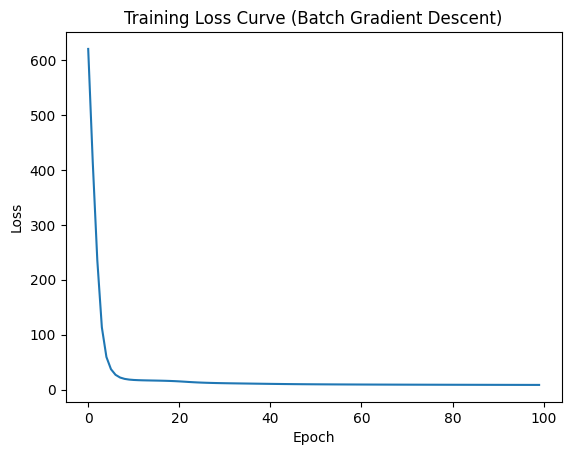

In [ ]:
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve (Batch Gradient Descent)")
plt.show()


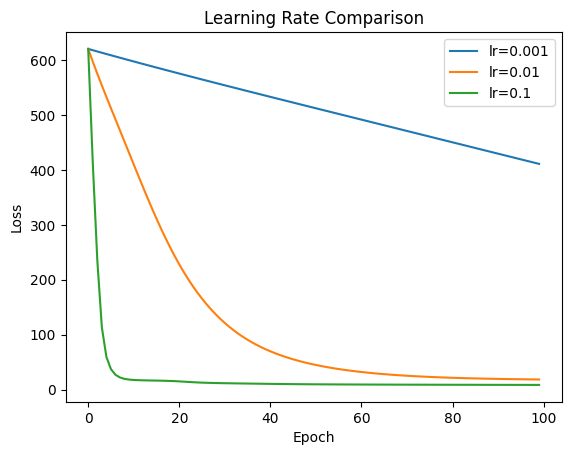

In [ ]:
# --- Compare effect of different fixed learning rates (0.001, 0.01, 0.1)
def train_model(lr):

    np.random.seed(42)
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, output_size) * 0.1
    b2 = np.zeros((1, output_size))

    epochs = 100
    loss_history = []

    for epoch in range(epochs):

        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-Z1))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    return loss_history


loss_lr_001 = train_model(0.001)
loss_lr_01 = train_model(0.01)
loss_lr_1 = train_model(0.1)

import matplotlib.pyplot as plt

plt.plot(loss_lr_001, label="lr=0.001")
plt.plot(loss_lr_01, label="lr=0.01")
plt.plot(loss_lr_1, label="lr=0.1")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Learning Rate Comparison")
plt.legend()
plt.show()


In [ ]:
# Study effect of hidden layer size (1,2,3,5,10 neurons) on train and test loss
def train_with_hidden_size(hidden_size, lr=0.1, epochs=100):

    np.random.seed(42)

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    for epoch in range(epochs):

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-Z1))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

    # Final training loss
    train_loss = np.mean((y_train - y_pred) ** 2)

    # Test loss
    Z1_test = np.dot(X_test_scaled, W1) + b1
    A1_test = 1 / (1 + np.exp(-Z1_test))
    Z2_test = np.dot(A1_test, W2) + b2
    y_test_pred = Z2_test

    test_loss = np.mean((y_test - y_test_pred) ** 2)

    return train_loss, test_loss


hidden_sizes = [1, 2, 3, 5, 10]

for h in hidden_sizes:
    train_loss, test_loss = train_with_hidden_size(h)
    print(f"Hidden neurons: {h} | Train Loss: {train_loss:.4f} | Test Loss: {test_loss:.4f}")


Hidden neurons: 1 | Train Loss: 13.2245 | Test Loss: 11.6304
Hidden neurons: 2 | Train Loss: 9.5257 | Test Loss: 9.4644
Hidden neurons: 3 | Train Loss: 8.5552 | Test Loss: 7.8090
Hidden neurons: 5 | Train Loss: 8.7439 | Test Loss: 8.2771
Hidden neurons: 10 | Train Loss: 7.8834 | Test Loss: 7.2272


In [ ]:
# --- Batch Training: use entire dataset at once, update weights once per epoch ---
def train_batch(hidden_size=10, lr=0.1, epochs=100):

    np.random.seed(42)

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-Z1))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")
            print(f"  W1 (8→10):\n{W1.round(4)}")
            print(f"  W2 (10→1):\n{W2.round(4)}")
            print()

    return loss_history, W1, b1, W2, b2

batch_loss = train_batch()

Epoch 0, Loss: 615.6238
  W1 (8→10):
[[ 0.0462 -0.0082  0.0884  0.1449 -0.0361 -0.0313  0.172   0.0817 -0.0553
   0.0623]
 [-0.0427 -0.0526 -0.0008 -0.1833 -0.1591 -0.0479 -0.1163  0.0261 -0.082
  -0.1498]
 [ 0.1442 -0.0186  0.0236 -0.1483 -0.0632  0.0054 -0.1049  0.0412 -0.0661
  -0.0235]
 [-0.0554  0.1774 -0.0339 -0.0951  0.0996 -0.1111  0.0013 -0.2029 -0.1212
   0.0086]
 [ 0.0689  0.0252  0.022  -0.0414 -0.1658 -0.0833 -0.0256  0.1129  0.0224
  -0.1648]
 [ 0.0325 -0.0386 -0.068   0.0613  0.1031  0.0933 -0.084  -0.0309  0.0333
   0.0975]
 [-0.0496 -0.0159 -0.0995 -0.1234  0.0751  0.1319 -0.0004  0.1026  0.0322
  -0.0606]
 [ 0.0357  0.1546 -0.0006  0.1556 -0.2632  0.0812  0.0105 -0.0292  0.0081
  -0.1978]]
  W2 (10→1):
[[1.1674]
 [1.1341]
 [1.2745]
 [1.1272]
 [1.0184]
 [1.1092]
 [1.2355]
 [1.2476]
 [1.1182]
 [1.1576]]

Epoch 10, Loss: 14.4460
  W1 (8→10):
[[ 0.196   0.1077  0.2737  0.343   0.1091  0.0526  0.35    0.2066  0.087
   0.2641]
 [-0.2462 -0.2308 -0.2399 -0.4412 -0.3666 -0.19

In [ ]:
# SGD Training: iterate through all 614 samples one by one, updating weights after each
def train_sgd(hidden_size=10, lr=0.1, epochs=100):

    np.random.seed(42)

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-Z1))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Compute full training loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-Z1_full))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")
            print(f"  W1 (8→10):\n{W1.round(4)}")
            print(f"  W2 (10→1):\n{W2.round(4)}")
            print()

    return loss_history, W1, b1, W2, b2


In [ ]:
sgd_loss = train_sgd()


Epoch 0, Loss: 16.1814
  W1 (8→10):
[[-1.8758 -4.7005  0.0181  0.0557  1.2018  1.5377  1.4281  1.5643  1.1351
   1.414 ]
 [ 1.7625  3.9219  0.217  -1.1497 -1.372  -1.6402 -1.1574 -1.7466 -1.1942
  -1.5788]
 [ 5.3601  4.5603  1.7806  5.3639  2.0628  1.8503  2.3121 -1.1171  2.1925
   1.8031]
 [-0.7959  1.8699 -0.666  -3.695  -2.1125 -2.5599 -2.1824 -1.3832 -2.2985
  -2.2712]
 [ 0.69   -0.5921  0.0081  4.8242  1.5537  1.7449  1.6998  1.8788  1.7645
   1.6232]
 [ 0.0196  0.1556  1.1827  1.9805 -0.043   0.1113 -0.0987 -3.292   0.4255
  -0.2204]
 [ 1.6973  0.6196  0.7026  3.4068  0.4991  0.9353  0.595   5.182   0.1265
   0.4918]
 [ 2.221   0.0527 -2.4844  0.0123 -0.5033  0.1444 -0.0844 -0.4614 -0.1546
  -0.5056]]
  W2 (10→1):
[[2.9243]
 [5.1116]
 [0.2669]
 [4.4077]
 [3.6641]
 [3.3771]
 [4.6638]
 [3.5397]
 [3.9686]
 [3.0281]]

Epoch 10, Loss: 4.4959
  W1 (8→10):
[[-3.55570e+00 -9.56610e+00  4.43520e+00 -1.35350e+00  1.76440e+00
  -1.05520e+00  1.61300e-01 -1.33100e-01  1.91630e+00  1.99320e+0

In [ ]:
# Mini-Batch Training: shuffle data each epoch, update weights after every 32 samples
def train_minibatch(hidden_size=10, lr=0.1, epochs=100, batch_size=32):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Shuffle data every epoch
        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-Z1))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full training loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-Z1_full))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss:.4f}")
            print(f"  W1 (8→10):\n{W1.round(4)}")
            print(f"  W2 (10→1):\n{W2.round(4)}")
            print()

    return loss_history, W1, b1, W2, b2


mini_loss = train_minibatch()



Epoch 0, Loss: 12.3097
  W1 (8→10):
[[ 0.1236 -0.1737  0.3108  0.3462 -0.1486 -0.2956  0.3787  0.1843 -0.0337
   0.2714]
 [-0.25   -0.0337 -0.3458 -0.5059 -0.1904  0.0655 -0.4471 -0.2052 -0.2394
  -0.484 ]
 [ 0.726   0.7246  0.6102  0.4916  0.6829  0.7505  0.5323  0.6089  0.5827
   0.612 ]
 [-0.5386 -0.1618 -0.6544 -0.7193 -0.2902 -0.3585 -0.6297 -0.7029 -0.5878
  -0.6249]
 [ 0.7402  0.5756  0.8074  0.7451  0.4239  0.3918  0.766   0.794   0.6777
   0.6331]
 [-0.0724 -0.1272 -0.1475 -0.0319  0.0039 -0.0013 -0.1623 -0.1356 -0.0781
  -0.0179]
 [ 0.4623  0.6821  0.3302  0.3022  0.697   0.8167  0.3935  0.524   0.5637
   0.3663]
 [ 0.111   0.3051  0.0163  0.1907 -0.0749  0.2427  0.0453  0.0245  0.1272
  -0.1016]]
  W2 (10→1):
[[3.2152]
 [2.9878]
 [3.3022]
 [3.0381]
 [2.7767]
 [3.0604]
 [3.2111]
 [3.3858]
 [3.0713]
 [3.0448]]

Epoch 10, Loss: 6.8037
  W1 (8→10):
[[-0.3803 -0.3702  0.5941  0.5779 -0.3239 -1.2782  0.6944 -0.0665 -0.4923
   0.5659]
 [-0.0537  0.1027 -0.8025 -0.9046 -0.1994  1.04

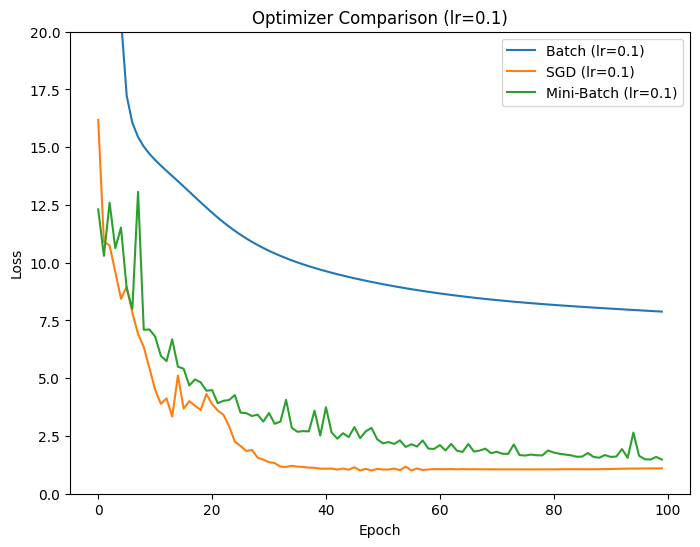

In [ ]:
# Optimizer Comparison
plt.figure(figsize=(8,6))

plt.plot(batch_loss[0], label="Batch (lr=0.1)")
plt.plot(sgd_loss[0], label="SGD (lr=0.1)")
plt.plot(mini_loss[0], label="Mini-Batch (lr=0.1)")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Optimizer Comparison (lr=0.1)")
plt.legend()
plt.ylim(0, 20)   # tighter zoom
plt.show()


In [ ]:
#Mini-Batch + Classical Momentum

def train_momentum(hidden_size=10, lr=0.05, epochs=100, batch_size=32, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    # Initialize velocity
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-Z1))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Momentum update
            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1

        # Compute full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-Z1_full))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


momentum_loss = train_momentum()


Epoch 0, Loss: 43.17367175543181
Epoch 10, Loss: 3.7832372019628617
Epoch 20, Loss: 2.8704882859604877
Epoch 30, Loss: 2.9155924511537945
Epoch 40, Loss: 2.3671196042856257
Epoch 50, Loss: 1.8459095288696152
Epoch 60, Loss: 1.4512769489807362
Epoch 70, Loss: 1.6628299372389173
Epoch 80, Loss: 2.39961007932674
Epoch 90, Loss: 1.1448583911275583


In [ ]:
# Batch + Classical Momentum
def train_batch_momentum(hidden_size=10, lr=0.05, epochs=100, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        # Forward (FULL DATA)
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-Z1))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Momentum update
        vW2 = beta * vW2 - lr * dW2
        vb2 = beta * vb2 - lr * db2
        vW1 = beta * vW1 - lr * dW1
        vb1 = beta * vb1 - lr * db1

        W2 += vW2
        b2 += vb2
        W1 += vW1
        b1 += vb1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


batch_momentum_loss = train_batch_momentum()


Epoch 0, Loss: 615.6237797163642
Epoch 10, Loss: 75.72409976121597
Epoch 20, Loss: 37.78531757602709
Epoch 30, Loss: 13.411381227909562
Epoch 40, Loss: 15.354234342750152
Epoch 50, Loss: 9.465016626445731
Epoch 60, Loss: 8.150808484767657
Epoch 70, Loss: 7.465341292148007
Epoch 80, Loss: 6.775887425727266
Epoch 90, Loss: 6.410768342467425


In [ ]:
# SGD + Classical Momentum
def train_sgd_momentum(hidden_size=10, lr=0.01, epochs=100, beta=0.9):

    np.random.seed(42)

    # Initialize weights
    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    # Initialize velocity
    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward pass
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))  # stable sigmoid
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backpropagation
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Momentum update
            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            # Apply update
            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1

        # Compute full loss after each epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


sgd_momentum_loss = train_sgd_momentum()


Epoch 0, Loss: 18.24157431218242
Epoch 10, Loss: 4.821332801192362
Epoch 20, Loss: 4.074872490114056
Epoch 30, Loss: 3.9402736637004745
Epoch 40, Loss: 3.4465413123188915
Epoch 50, Loss: 3.634097447494643
Epoch 60, Loss: 3.5197023304506616
Epoch 70, Loss: 3.5181766200463236
Epoch 80, Loss: 3.403808318462927
Epoch 90, Loss: 3.2876282803517936


In [ ]:
# Batch + Nesterov Momentum
def train_batch_nesterov(hidden_size=10, lr=0.05, epochs=100, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        # Lookahead weights
        W1_look = W1 + beta * vW1
        b1_look = b1 + beta * vb1
        W2_look = W2 + beta * vW2
        b2_look = b2 + beta * vb2

        # Forward pass
        Z1 = np.dot(X_train_scaled, W1_look) + b1_look
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2_look) + b2_look
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2_look.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Velocity update
        vW2 = beta * vW2 - lr * dW2
        vb2 = beta * vb2 - lr * db2
        vW1 = beta * vW1 - lr * dW1
        vb1 = beta * vb1 - lr * db1

        # Weight update
        W2 += vW2
        b2 += vb2
        W1 += vW1
        b1 += vb1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
batch_nesterov_loss = train_batch_nesterov()


Epoch 0, Loss: 615.6237797163642
Epoch 10, Loss: 17.827780840584428
Epoch 20, Loss: 9.478647263305682
Epoch 30, Loss: 8.393264868383886
Epoch 40, Loss: 7.725783685140828
Epoch 50, Loss: 7.203924620546903
Epoch 60, Loss: 6.877254704934142
Epoch 70, Loss: 6.522626398155261
Epoch 80, Loss: 6.183116130110913
Epoch 90, Loss: 5.88833937022248


In [ ]:
# Mini Batch + Nesterov Momentum

def train_minibatch_nesterov(hidden_size=10, lr=0.05, epochs=100, batch_size=32, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Lookahead
            W1_look = W1 + beta * vW1
            b1_look = b1 + beta * vb1
            W2_look = W2 + beta * vW2
            b2_look = b2 + beta * vb2

            Z1 = np.dot(X_batch, W1_look) + b1_look
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2_look) + b2_look
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2_look.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2

mini_nesterov_loss = train_minibatch_nesterov()



Epoch 0, Loss: 11.819826926218216
Epoch 10, Loss: 3.288967461928629
Epoch 20, Loss: 1.888127935683303
Epoch 30, Loss: 1.7622242310078076
Epoch 40, Loss: 1.6959594764617556
Epoch 50, Loss: 1.4889940701695827
Epoch 60, Loss: 1.3791322868026168
Epoch 70, Loss: 1.5886571872313493
Epoch 80, Loss: 1.407781389615265
Epoch 90, Loss: 1.324087000383381


In [ ]:
# SGD + Nesterov Momentum

def train_sgd_nesterov(hidden_size=10, lr=0.01, epochs=100, beta=0.9):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            W1_look = W1 + beta * vW1
            b1_look = b1 + beta * vb1
            W2_look = W2 + beta * vW2
            b2_look = b2 + beta * vb2

            Z1 = np.dot(x_i, W1_look) + b1_look
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2_look) + b2_look
            y_pred = Z2

            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2_look.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            vW2 = beta * vW2 - lr * dW2
            vb2 = beta * vb2 - lr * db2
            vW1 = beta * vW1 - lr * dW1
            vb1 = beta * vb1 - lr * db1

            W2 += vW2
            b2 += vb2
            W1 += vW1
            b1 += vb1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2

sgd_nesterov_loss = train_sgd_nesterov()



Epoch 0, Loss: 13.21057196443672
Epoch 10, Loss: 3.330506477153375
Epoch 20, Loss: 3.033413116836678
Epoch 30, Loss: 3.475112412631786
Epoch 40, Loss: 2.2304849730251926
Epoch 50, Loss: 3.5652205464565303
Epoch 60, Loss: 1.8631676992383475
Epoch 70, Loss: 1.4530016872342066
Epoch 80, Loss: 1.3892424626567628
Epoch 90, Loss: 1.3307241302697785


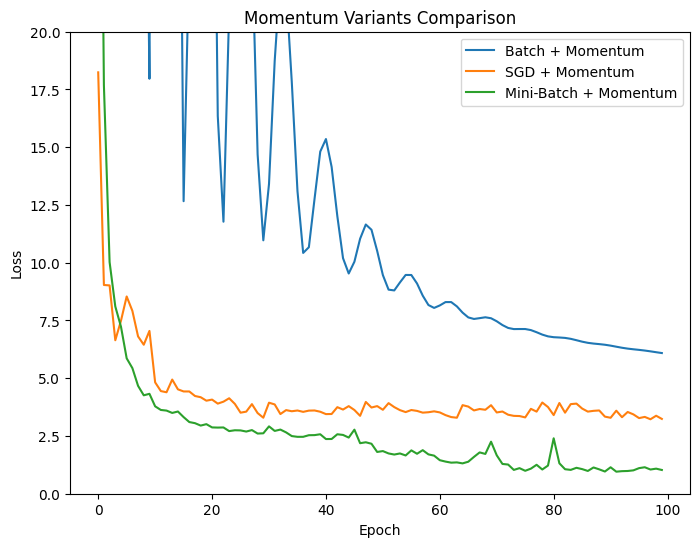

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(batch_momentum_loss[0], label="Batch + Momentum")
plt.plot(sgd_momentum_loss[0], label="SGD + Momentum")
plt.plot(momentum_loss[0], label="Mini-Batch + Momentum")

plt.title("Momentum Variants Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 20)
plt.show()


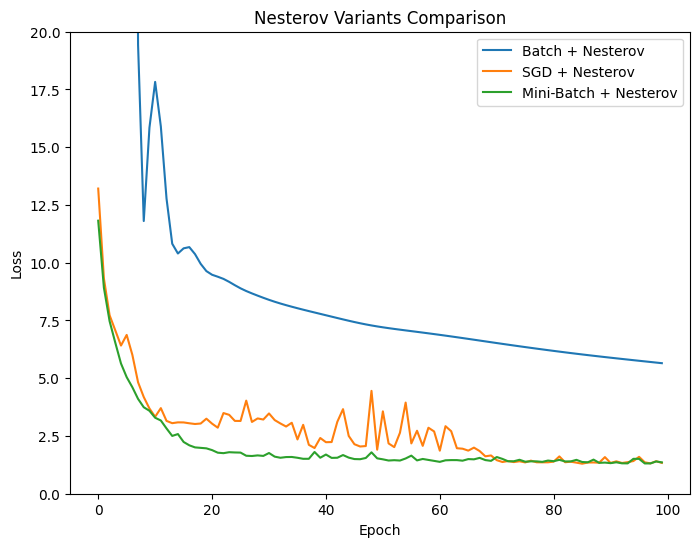

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(batch_nesterov_loss[0], label="Batch + Nesterov")
plt.plot(sgd_nesterov_loss[0], label="SGD + Nesterov")
plt.plot(mini_nesterov_loss[0], label="Mini-Batch + Nesterov")

plt.title("Nesterov Variants Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 20)
plt.show()


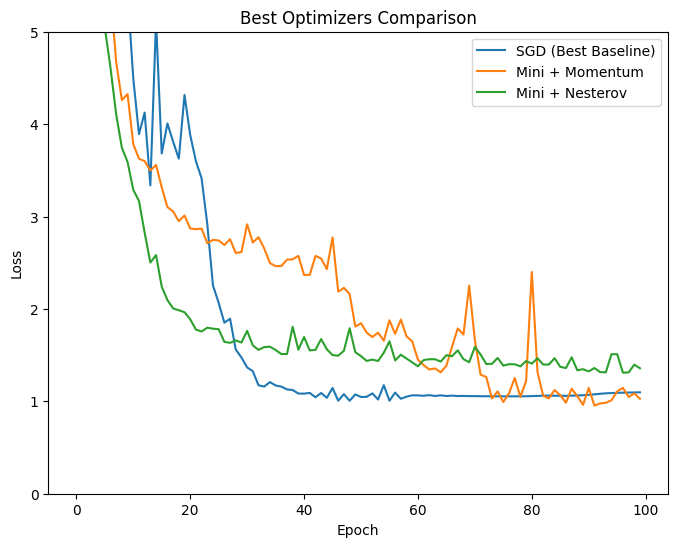

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(sgd_loss[0], label="SGD (Best Baseline)")
plt.plot(momentum_loss[0], label="Mini + Momentum")
plt.plot(mini_nesterov_loss[0], label="Mini + Nesterov")

plt.title("Best Optimizers Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 5)
plt.show()


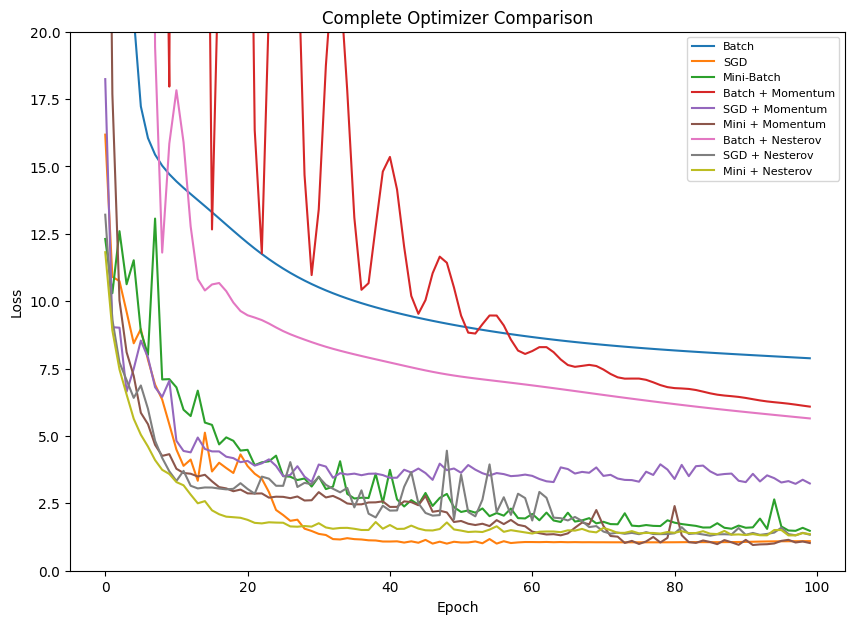

In [ ]:
plt.figure(figsize=(10,7))

# Baseline
plt.plot(batch_loss[0], label="Batch")
plt.plot(sgd_loss[0], label="SGD")
plt.plot(mini_loss[0], label="Mini-Batch")

# Momentum
plt.plot(batch_momentum_loss[0], label="Batch + Momentum")
plt.plot(sgd_momentum_loss[0], label="SGD + Momentum")
plt.plot(momentum_loss[0], label="Mini + Momentum")

# Nesterov
plt.plot(batch_nesterov_loss[0], label="Batch + Nesterov")
plt.plot(sgd_nesterov_loss[0], label="SGD + Nesterov")
plt.plot(mini_nesterov_loss[0], label="Mini + Nesterov")

plt.title("Complete Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right", fontsize=8)
plt.ylim(0, 20)
plt.show()


In [ ]:
# Batch Gradient Descent with Time-Based Learning Rate Decay

def train_batch_time_decay(hidden_size=10, initial_lr=0.1, decay_rate=0.01, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Time-based learning rate
        lr = initial_lr / (1 + decay_rate * epoch)

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.4f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
batch_time_loss = train_batch_time_decay()


Epoch 0, LR: 0.1000, Loss: 615.6237797163642
Epoch 10, LR: 0.0909, Loss: 14.555713897629374
Epoch 20, LR: 0.0833, Loss: 12.53377227800337
Epoch 30, LR: 0.0769, Loss: 10.995628480202503
Epoch 40, LR: 0.0714, Loss: 10.119510028204024
Epoch 50, LR: 0.0667, Loss: 9.583281538168562
Epoch 60, LR: 0.0625, Loss: 9.207966374730225
Epoch 70, LR: 0.0588, Loss: 8.923925667766369
Epoch 80, LR: 0.0556, Loss: 8.702860336168701
Epoch 90, LR: 0.0526, Loss: 8.529000110655854


In [ ]:
# SGD with Time-Based Learning Rate Decay
# Learning rate decreases over epochs to allow smoother convergence

def train_sgd_time_decay(hidden_size=10, initial_lr=0.01, decay_rate=0.01, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Time-based learning rate
        lr = initial_lr / (1 + decay_rate * epoch)

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")


    return loss_history, W1, b1, W2, b2
sgd_time_loss, W1_sgd, b1_sgd, W2_sgd, b2_sgd = train_sgd_time_decay()


Epoch 0, LR: 0.01000, Loss: 10.36841207356151
Epoch 10, LR: 0.00909, Loss: 3.21464662567304
Epoch 20, LR: 0.00833, Loss: 1.703450935877947
Epoch 30, LR: 0.00769, Loss: 1.1619895401448057
Epoch 40, LR: 0.00714, Loss: 0.8865210180876145
Epoch 50, LR: 0.00667, Loss: 0.7435502004221728
Epoch 60, LR: 0.00625, Loss: 0.6544148758853355
Epoch 70, LR: 0.00588, Loss: 0.6028648630594312
Epoch 80, LR: 0.00556, Loss: 0.5690992120433894
Epoch 90, LR: 0.00526, Loss: 0.5443729341469541


In [ ]:
# Mini-Batch Gradient Descent with Time-Based Learning Rate Decay
# Learning rate decreases gradually over epochs

def train_minibatch_time_decay(hidden_size=10, initial_lr=0.05, decay_rate=0.01,
                                epochs=100, batch_size=32):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Time-based learning rate
        lr = initial_lr / (1 + decay_rate * epoch)

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Compute full loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
mini_time_loss = train_minibatch_time_decay()


Epoch 0, LR: 0.05000, Loss: 14.938385642664691
Epoch 10, LR: 0.04545, Loss: 8.072652091871534
Epoch 20, LR: 0.04167, Loss: 6.510477313546884
Epoch 30, LR: 0.03846, Loss: 5.464358484849558
Epoch 40, LR: 0.03571, Loss: 5.211021330582608
Epoch 50, LR: 0.03333, Loss: 3.8998255310084584
Epoch 60, LR: 0.03125, Loss: 3.7103608975807463
Epoch 70, LR: 0.02941, Loss: 3.2210227538627625
Epoch 80, LR: 0.02778, Loss: 3.011931644404614
Epoch 90, LR: 0.02632, Loss: 2.8419124675390712


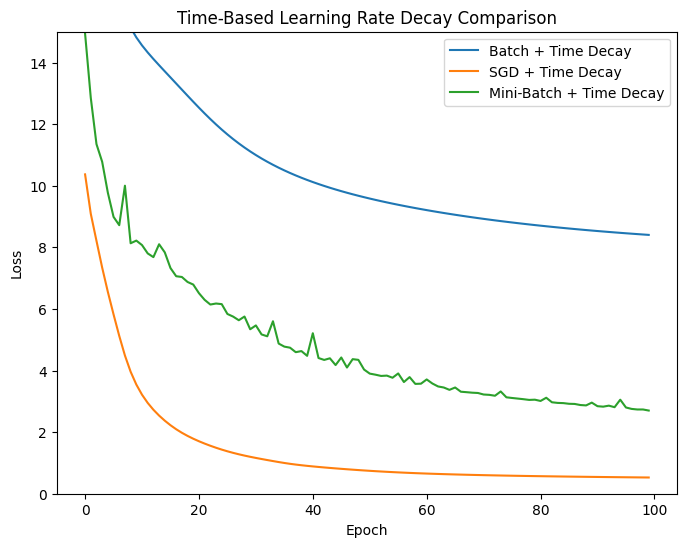

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(batch_time_loss[0], label="Batch + Time Decay")
plt.plot(sgd_time_loss, label="SGD + Time Decay")
plt.plot(mini_time_loss[0], label="Mini-Batch + Time Decay")

plt.title("Time-Based Learning Rate Decay Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 15)
plt.show()


In [ ]:
# Batch Gradient Descent with Step Decay
# Learning rate drops by a fixed factor every 'step_size' epochs

def train_batch_step_decay(hidden_size=10, initial_lr=0.1, drop=0.5,
                           step_size=20, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Step decay formula
        lr = initial_lr * (drop ** (epoch // step_size))

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
batch_step_loss = train_batch_step_decay()


Epoch 0, LR: 0.10000, Loss: 615.6237797163642
Epoch 10, LR: 0.10000, Loss: 14.446019593455658
Epoch 20, LR: 0.05000, Loss: 12.166047233951533
Epoch 30, LR: 0.05000, Loss: 11.215064341143625
Epoch 40, LR: 0.02500, Loss: 10.521210315311883
Epoch 50, LR: 0.02500, Loss: 10.251265632645733
Epoch 60, LR: 0.01250, Loss: 10.018972043892978
Epoch 70, LR: 0.01250, Loss: 9.914582196562217
Epoch 80, LR: 0.00625, Loss: 9.816708448972784
Epoch 90, LR: 0.00625, Loss: 9.770010392135228


In [ ]:
# Mini-Batch Gradient Descent with Step Decay
# Learning rate drops by a fixed factor every 'step_size' epochs

def train_minibatch_step_decay(hidden_size=10, initial_lr=0.05, drop=0.5,
                               step_size=20, epochs=100, batch_size=32):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Step decay formula
        lr = initial_lr * (drop ** (epoch // step_size))

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
mini_step_loss = train_minibatch_step_decay()


Epoch 0, LR: 0.05000, Loss: 14.938385642664691
Epoch 10, LR: 0.05000, Loss: 8.058711465956602
Epoch 20, LR: 0.02500, Loss: 6.196118484909608
Epoch 30, LR: 0.02500, Loss: 5.520668104153753
Epoch 40, LR: 0.01250, Loss: 4.948809230766289
Epoch 50, LR: 0.01250, Loss: 4.566848157662754
Epoch 60, LR: 0.00625, Loss: 4.350132723585085
Epoch 70, LR: 0.00625, Loss: 4.231904958963163
Epoch 80, LR: 0.00313, Loss: 4.138470936816566
Epoch 90, LR: 0.00313, Loss: 4.089664455707721


In [ ]:
# SGD with Step Learning Rate Decay
# Learning rate drops by a fixed factor every 'step_size' epochs

def train_sgd_step_decay(hidden_size=10, initial_lr=0.01, drop=0.5,
                         step_size=20, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Step decay formula
        lr = initial_lr * (drop ** (epoch // step_size))

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss after epoch
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
sgd_step_loss = train_sgd_step_decay()


Epoch 0, LR: 0.01000, Loss: 10.36841207356151
Epoch 10, LR: 0.01000, Loss: 3.1115423574991667
Epoch 20, LR: 0.00500, Loss: 1.5332303852750855
Epoch 30, LR: 0.00500, Loss: 1.2011012075145096
Epoch 40, LR: 0.00250, Loss: 0.9719987395729199
Epoch 50, LR: 0.00250, Loss: 0.8791208348169556
Epoch 60, LR: 0.00125, Loss: 0.8088511995706821
Epoch 70, LR: 0.00125, Loss: 0.7792871824789445
Epoch 80, LR: 0.00063, Loss: 0.753695472249714
Epoch 90, LR: 0.00063, Loss: 0.7410843405037096


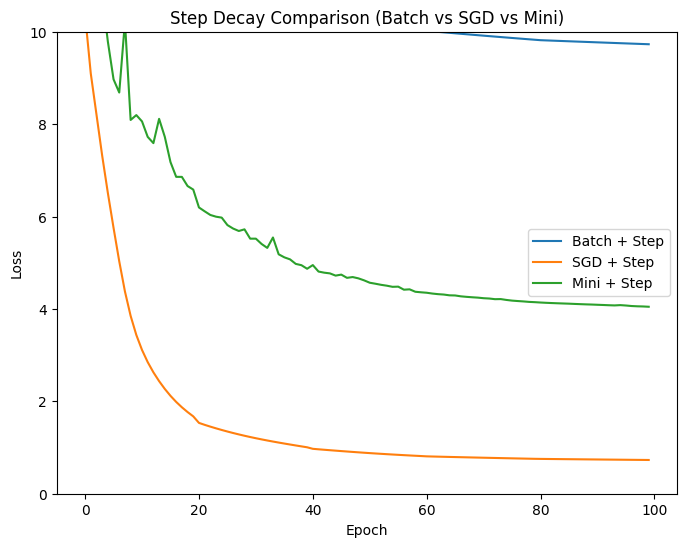

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(batch_step_loss[0], label="Batch + Step")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(mini_step_loss[0], label="Mini + Step")

plt.title("Step Decay Comparison (Batch vs SGD vs Mini)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 10)
plt.show()


In [ ]:
# Batch Gradient Descent with Exponential Decay
# Learning rate decays exponentially over epochs

def train_batch_exp_decay(hidden_size=10, initial_lr=0.1,
                          decay_rate=0.05, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        # Exponential decay
        lr = initial_lr * np.exp(-decay_rate * epoch)

        # Forward
        Z1 = np.dot(X_train_scaled, W1) + b1
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2) + b2
        y_pred = Z2

        loss = np.mean((y_train - y_pred) ** 2)
        loss_history.append(loss)

        # Backprop
        n = y_train.shape[0]
        dZ2 = (y_pred - y_train) / n
        dW2 = np.dot(A1.T, dZ2)
        db2 = np.sum(dZ2, axis=0, keepdims=True)

        dA1 = np.dot(dZ2, W2.T)
        dZ1 = dA1 * (A1 * (1 - A1))
        dW1 = np.dot(X_train_scaled.T, dZ1)
        db1 = np.sum(dZ1, axis=0, keepdims=True)

        # Update
        W2 -= lr * dW2
        b2 -= lr * db2
        W1 -= lr * dW1
        b1 -= lr * db1

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
batch_exp_loss = train_batch_exp_decay()

Epoch 0, LR: 0.10000, Loss: 615.6237797163642
Epoch 10, LR: 0.06065, Loss: 15.02784781910295
Epoch 20, LR: 0.03679, Loss: 13.746655780229501
Epoch 30, LR: 0.02231, Loss: 13.059142687756852
Epoch 40, LR: 0.01353, Loss: 12.639328153775887
Epoch 50, LR: 0.00821, Loss: 12.390273218850782
Epoch 60, LR: 0.00498, Loss: 12.243048175983464
Epoch 70, LR: 0.00302, Loss: 12.155504299005395
Epoch 80, LR: 0.00183, Loss: 12.103115252291012
Epoch 90, LR: 0.00111, Loss: 12.07161303880916


In [ ]:
# SGD with Exponential Decay

def train_sgd_exp_decay(hidden_size=10, initial_lr=0.01,
                        decay_rate=0.05, epochs=100):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        lr = initial_lr * np.exp(-decay_rate * epoch)

        for i in range(X_train_scaled.shape[0]):

            x_i = X_train_scaled[i:i+1]
            y_i = y_train[i:i+1]

            # Forward
            Z1 = np.dot(x_i, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            dZ2 = (y_pred - y_i)
            dW2 = np.dot(A1.T, dZ2)
            db2 = dZ2

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(x_i.T, dZ1)
            db1 = dZ1

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
sgd_exp_loss = train_sgd_exp_decay()

Epoch 0, LR: 0.01000, Loss: 10.36841207356151
Epoch 10, LR: 0.00607, Loss: 3.7070902581486593
Epoch 20, LR: 0.00368, Loss: 2.2640390520961007
Epoch 30, LR: 0.00223, Loss: 1.8332880778659228
Epoch 40, LR: 0.00135, Loss: 1.6515992313834904
Epoch 50, LR: 0.00082, Loss: 1.5586180913811227
Epoch 60, LR: 0.00050, Loss: 1.5070492458427753
Epoch 70, LR: 0.00030, Loss: 1.4773388344389597
Epoch 80, LR: 0.00018, Loss: 1.4598756674959252
Epoch 90, LR: 0.00011, Loss: 1.449487587822835


In [ ]:
# Mini-Batch Gradient Descent with Exponential Decay

def train_minibatch_exp_decay(hidden_size=10, initial_lr=0.05,
                              decay_rate=0.05, epochs=100, batch_size=32):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    loss_history = []

    for epoch in range(epochs):

        lr = initial_lr * np.exp(-decay_rate * epoch)

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            # Forward
            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            # Backprop
            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Update
            W2 -= lr * dW2
            b2 -= lr * db2
            W1 -= lr * dW1
            b1 -= lr * db1

        # Full loss
        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred) ** 2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, LR: {lr:.5f}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2
mini_exp_loss = train_minibatch_exp_decay()

Epoch 0, LR: 0.05000, Loss: 14.938385642664691
Epoch 10, LR: 0.03033, Loss: 8.180787184008887
Epoch 20, LR: 0.01839, Loss: 7.439455367345635
Epoch 30, LR: 0.01116, Loss: 6.93467167268526
Epoch 40, LR: 0.00677, Loss: 6.666977516149895
Epoch 50, LR: 0.00410, Loss: 6.4314252144361905
Epoch 60, LR: 0.00249, Loss: 6.3223546055573205
Epoch 70, LR: 0.00151, Loss: 6.256972010646747
Epoch 80, LR: 0.00092, Loss: 6.218677245977199
Epoch 90, LR: 0.00056, Loss: 6.196024966601802


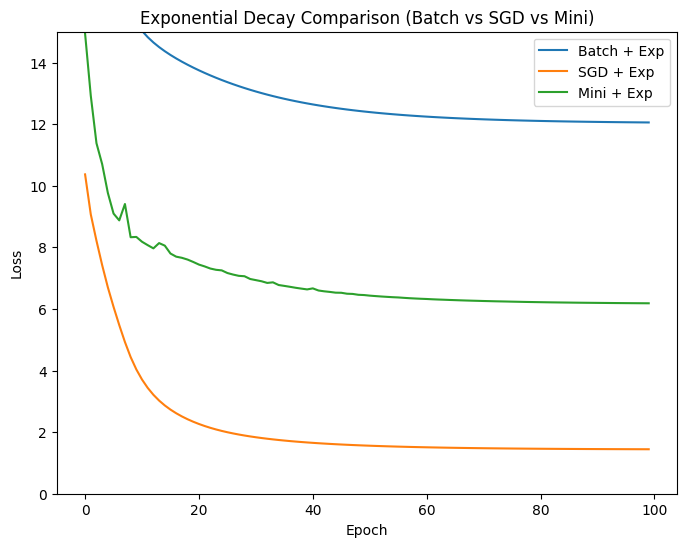

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(batch_exp_loss[0], label="Batch + Exp")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")
plt.plot(mini_exp_loss[0], label="Mini + Exp")

plt.title("Exponential Decay Comparison (Batch vs SGD vs Mini)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 15)
plt.show()


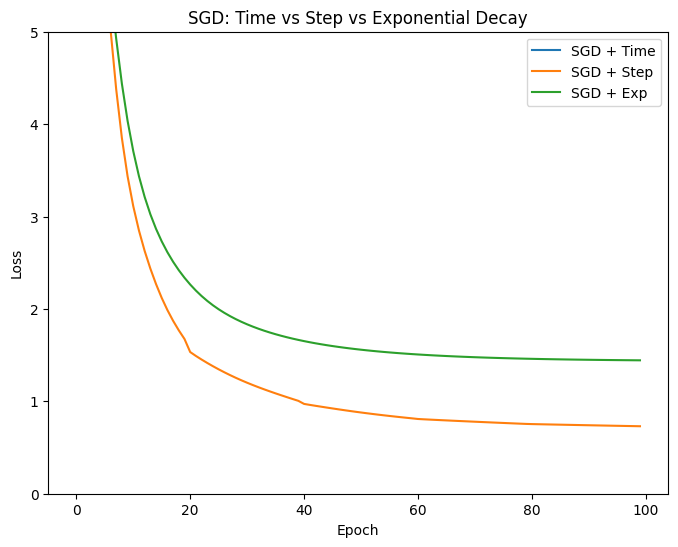

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(sgd_time_loss[0], label="SGD + Time")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")

plt.title("SGD: Time vs Step vs Exponential Decay")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.ylim(0, 5)
plt.show()


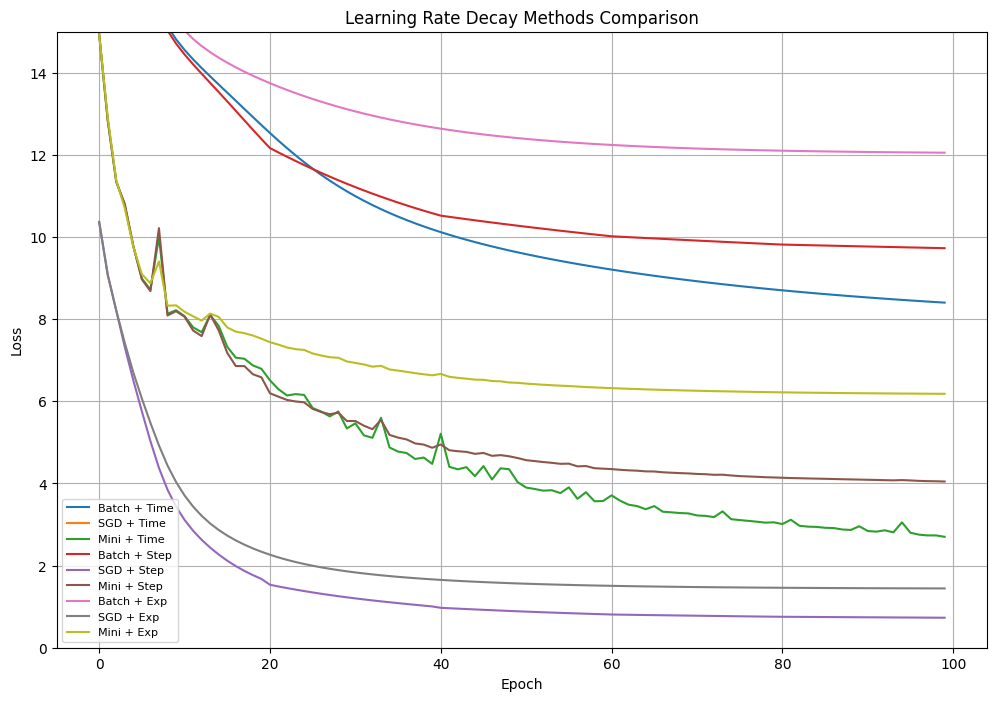

In [ ]:
plt.figure(figsize=(12,8))

# ===== TIME DECAY =====
plt.plot(batch_time_loss[0], label="Batch + Time")
plt.plot(sgd_time_loss[0], label="SGD + Time")
plt.plot(mini_time_loss[0], label="Mini + Time")

# ===== STEP DECAY =====
plt.plot(batch_step_loss[0], label="Batch + Step")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(mini_step_loss[0], label="Mini + Step")

# ===== EXPONENTIAL DECAY =====
plt.plot(batch_exp_loss[0], label="Batch + Exp")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")
plt.plot(mini_exp_loss[0], label="Mini + Exp")

plt.title("Learning Rate Decay Methods Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(fontsize=8)
plt.ylim(0, 15)
plt.grid(True)

plt.show()


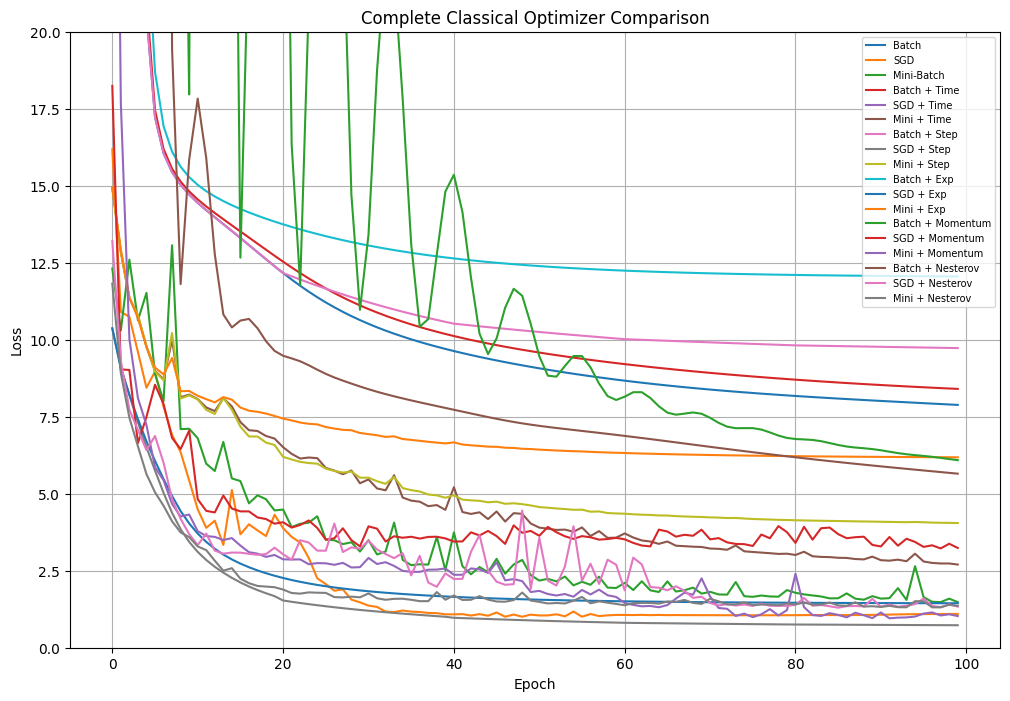

In [ ]:
plt.figure(figsize=(12,8))

# ================= BASELINE =================
plt.plot(batch_loss[0], label="Batch")
plt.plot(sgd_loss[0], label="SGD")
plt.plot(mini_loss[0], label="Mini-Batch")

# ================= TIME DECAY =================
plt.plot(batch_time_loss[0], label="Batch + Time")
plt.plot(sgd_time_loss[0], label="SGD + Time")
plt.plot(mini_time_loss[0], label="Mini + Time")

# ================= STEP DECAY =================
plt.plot(batch_step_loss[0], label="Batch + Step")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(mini_step_loss[0], label="Mini + Step")

# ================= EXP DECAY =================
plt.plot(batch_exp_loss[0], label="Batch + Exp")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")
plt.plot(mini_exp_loss[0], label="Mini + Exp")

# ================= MOMENTUM =================
plt.plot(batch_momentum_loss[0], label="Batch + Momentum")
plt.plot(sgd_momentum_loss[0], label="SGD + Momentum")
plt.plot(momentum_loss[0], label="Mini + Momentum")

# ================= NESTEROV =================
plt.plot(batch_nesterov_loss[0], label="Batch + Nesterov")
plt.plot(sgd_nesterov_loss[0], label="SGD + Nesterov")
plt.plot(mini_nesterov_loss[0], label="Mini + Nesterov")

plt.title("Complete Classical Optimizer Comparison")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend(loc="upper right", fontsize=7)
plt.ylim(0, 20)
plt.grid(True)

plt.show()


In [ ]:
# =====================================================
# Mini-Batch AdaGrad Optimizer
# Adaptive learning rate based on accumulated squared gradients
# =====================================================

def train_adagrad(hidden_size=10, lr=0.01, epochs=100,
                  batch_size=32, epsilon=1e-8):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    GW1 = np.zeros_like(W1)
    Gb1 = np.zeros_like(b1)
    GW2 = np.zeros_like(W2)
    Gb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            GW2 += dW2**2
            Gb2 += db2**2
            GW1 += dW1**2
            Gb1 += db1**2

            W2 -= lr * dW2 / (np.sqrt(GW2) + epsilon)
            b2 -= lr * db2 / (np.sqrt(Gb2) + epsilon)
            W1 -= lr * dW1 / (np.sqrt(GW1) + epsilon)
            b1 -= lr * db1 / (np.sqrt(Gb1) + epsilon)

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


adagrad_loss = train_adagrad()


Epoch 0, Loss: 593.5718851622343
Epoch 10, Loss: 521.1930398900361
Epoch 20, Loss: 480.1296058859602
Epoch 30, Loss: 449.0832130488775
Epoch 40, Loss: 423.4958066744061
Epoch 50, Loss: 401.19315564800775
Epoch 60, Loss: 381.3413465305709
Epoch 70, Loss: 363.236987902894
Epoch 80, Loss: 346.75401799916875
Epoch 90, Loss: 331.56954127657366


In [ ]:
# =====================================================
# Mini-Batch RMSProp Optimizer
# Exponential moving average of squared gradients
# =====================================================

def train_rmsprop(hidden_size=10, lr=0.001, epochs=100,
                  batch_size=32, beta=0.9, epsilon=1e-8):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    vW1 = np.zeros_like(W1)
    vb1 = np.zeros_like(b1)
    vW2 = np.zeros_like(W2)
    vb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            vW2 = beta * vW2 + (1-beta) * dW2**2
            vb2 = beta * vb2 + (1-beta) * db2**2
            vW1 = beta * vW1 + (1-beta) * dW1**2
            vb1 = beta * vb1 + (1-beta) * db1**2

            W2 -= lr * dW2 / (np.sqrt(vW2) + epsilon)
            b2 -= lr * db2 / (np.sqrt(vb2) + epsilon)
            W1 -= lr * dW1 / (np.sqrt(vW1) + epsilon)
            b1 -= lr * db1 / (np.sqrt(vb1) + epsilon)

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


rmsprop_loss = train_rmsprop()


Epoch 0, Loss: 607.3751252871646
Epoch 10, Loss: 543.5531290512903
Epoch 20, Loss: 474.3582917134858
Epoch 30, Loss: 407.18228048401886
Epoch 40, Loss: 342.7442232563092
Epoch 50, Loss: 281.34145906650537
Epoch 60, Loss: 224.76036451866364
Epoch 70, Loss: 174.38764169234165
Epoch 80, Loss: 131.70175297503954
Epoch 90, Loss: 96.88392572054867


In [ ]:
# =====================================================
# Mini-Batch Adam Optimizer
# Combines Momentum and RMSProp with bias correction
# =====================================================

def train_adam(hidden_size=10, lr=0.001, epochs=100,
               batch_size=32, beta1=0.9, beta2=0.999, epsilon=1e-8):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    mW1 = np.zeros_like(W1)
    vW1 = np.zeros_like(W1)
    mb1 = np.zeros_like(b1)
    vb1 = np.zeros_like(b1)

    mW2 = np.zeros_like(W2)
    vW2 = np.zeros_like(W2)
    mb2 = np.zeros_like(b2)
    vb2 = np.zeros_like(b2)

    loss_history = []
    t = 0

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            t += 1
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            mW2 = beta1 * mW2 + (1-beta1) * dW2
            vW2 = beta2 * vW2 + (1-beta2) * dW2**2
            mb2 = beta1 * mb2 + (1-beta1) * db2
            vb2 = beta2 * vb2 + (1-beta2) * db2**2

            mW1 = beta1 * mW1 + (1-beta1) * dW1
            vW1 = beta2 * vW1 + (1-beta2) * dW1**2
            mb1 = beta1 * mb1 + (1-beta1) * db1
            vb1 = beta2 * vb1 + (1-beta2) * db1**2

            mW2_hat = mW2 / (1 - beta1**t)
            vW2_hat = vW2 / (1 - beta2**t)
            mb2_hat = mb2 / (1 - beta1**t)
            vb2_hat = vb2 / (1 - beta2**t)

            mW1_hat = mW1 / (1 - beta1**t)
            vW1_hat = vW1 / (1 - beta2**t)
            mb1_hat = mb1 / (1 - beta1**t)
            vb1_hat = vb1 / (1 - beta2**t)

            W2 -= lr * mW2_hat / (np.sqrt(vW2_hat) + epsilon)
            b2 -= lr * mb2_hat / (np.sqrt(vb2_hat) + epsilon)
            W1 -= lr * mW1_hat / (np.sqrt(vW1_hat) + epsilon)
            b1 -= lr * mb1_hat / (np.sqrt(vb1_hat) + epsilon)

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


adam_loss = train_adam()


Epoch 0, Loss: 609.861008828315
Epoch 10, Loss: 543.7478080506755
Epoch 20, Loss: 468.5590551892276
Epoch 30, Loss: 397.86167827054305
Epoch 40, Loss: 331.07847546199355
Epoch 50, Loss: 271.2249987897663
Epoch 60, Loss: 220.7526804999939
Epoch 70, Loss: 179.2043019351805
Epoch 80, Loss: 145.87433413174276
Epoch 90, Loss: 119.13342936921264


In [ ]:
# =====================================================
# Mini-Batch Adamax Optimizer
# Variant of Adam using infinity norm
# =====================================================

def train_adamax(hidden_size=10, lr=0.002, epochs=100,
                 batch_size=32, beta1=0.9, beta2=0.999, epsilon=1e-8):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    mW1 = np.zeros_like(W1)
    uW1 = np.zeros_like(W1)
    mb1 = np.zeros_like(b1)
    ub1 = np.zeros_like(b1)

    mW2 = np.zeros_like(W2)
    uW2 = np.zeros_like(W2)
    mb2 = np.zeros_like(b2)
    ub2 = np.zeros_like(b2)

    loss_history = []
    t = 0

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            t += 1
            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # First moment
            mW2 = beta1 * mW2 + (1-beta1) * dW2
            mb2 = beta1 * mb2 + (1-beta1) * db2
            mW1 = beta1 * mW1 + (1-beta1) * dW1
            mb1 = beta1 * mb1 + (1-beta1) * db1

            # Infinity norm
            uW2 = np.maximum(beta2 * uW2, np.abs(dW2))
            ub2 = np.maximum(beta2 * ub2, np.abs(db2))
            uW1 = np.maximum(beta2 * uW1, np.abs(dW1))
            ub1 = np.maximum(beta2 * ub1, np.abs(db1))

            # Bias correction
            mW2_hat = mW2 / (1 - beta1**t)
            mb2_hat = mb2 / (1 - beta1**t)
            mW1_hat = mW1 / (1 - beta1**t)
            mb1_hat = mb1 / (1 - beta1**t)

            # Update
            W2 -= lr * mW2_hat / (uW2 + epsilon)
            b2 -= lr * mb2_hat / (ub2 + epsilon)
            W1 -= lr * mW1_hat / (uW1 + epsilon)
            b1 -= lr * mb1_hat / (ub1 + epsilon)

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


adamax_loss = train_adamax()


Epoch 0, Loss: 605.7419685442898
Epoch 10, Loss: 510.32466489025063
Epoch 20, Loss: 408.66389940208006
Epoch 30, Loss: 314.85317265286307
Epoch 40, Loss: 225.3608192482166
Epoch 50, Loss: 164.17231864570897
Epoch 60, Loss: 118.6599677412951
Epoch 70, Loss: 84.10844397906165
Epoch 80, Loss: 58.794733380161354
Epoch 90, Loss: 42.043654682656964


In [ ]:
# =====================================================
# Mini-Batch Adadelta Optimizer
# Adaptive method without manual learning rate
# =====================================================

def train_adadelta(hidden_size=10, epochs=100,
                   batch_size=32, rho=0.95, epsilon=1e-6):

    np.random.seed(42)

    W1 = np.random.randn(input_size, hidden_size) * 0.1
    b1 = np.zeros((1, hidden_size))
    W2 = np.random.randn(hidden_size, 1) * 0.1
    b2 = np.zeros((1, 1))

    EgW1 = np.zeros_like(W1)
    Egb1 = np.zeros_like(b1)
    EgW2 = np.zeros_like(W2)
    Egb2 = np.zeros_like(b2)

    EdW1 = np.zeros_like(W1)
    Edb1 = np.zeros_like(b1)
    EdW2 = np.zeros_like(W2)
    Edb2 = np.zeros_like(b2)

    loss_history = []

    for epoch in range(epochs):

        indices = np.random.permutation(X_train_scaled.shape[0])
        X_shuffled = X_train_scaled[indices]
        y_shuffled = y_train[indices]

        for i in range(0, X_shuffled.shape[0], batch_size):

            X_batch = X_shuffled[i:i+batch_size]
            y_batch = y_shuffled[i:i+batch_size]

            Z1 = np.dot(X_batch, W1) + b1
            A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
            Z2 = np.dot(A1, W2) + b2
            y_pred = Z2

            n_batch = y_batch.shape[0]
            dZ2 = (y_pred - y_batch) / n_batch
            dW2 = np.dot(A1.T, dZ2)
            db2 = np.sum(dZ2, axis=0, keepdims=True)

            dA1 = np.dot(dZ2, W2.T)
            dZ1 = dA1 * (A1 * (1 - A1))
            dW1 = np.dot(X_batch.T, dZ1)
            db1 = np.sum(dZ1, axis=0, keepdims=True)

            # Accumulate gradient
            EgW2 = rho * EgW2 + (1-rho) * dW2**2
            Egb2 = rho * Egb2 + (1-rho) * db2**2
            EgW1 = rho * EgW1 + (1-rho) * dW1**2
            Egb1 = rho * Egb1 + (1-rho) * db1**2

            # Compute update
            delta_W2 = - (np.sqrt(EdW2 + epsilon) / np.sqrt(EgW2 + epsilon)) * dW2
            delta_b2 = - (np.sqrt(Edb2 + epsilon) / np.sqrt(Egb2 + epsilon)) * db2
            delta_W1 = - (np.sqrt(EdW1 + epsilon) / np.sqrt(EgW1 + epsilon)) * dW1
            delta_b1 = - (np.sqrt(Edb1 + epsilon) / np.sqrt(Egb1 + epsilon)) * db1

            # Apply update
            W2 += delta_W2
            b2 += delta_b2
            W1 += delta_W1
            b1 += delta_b1

            # Accumulate updates
            EdW2 = rho * EdW2 + (1-rho) * delta_W2**2
            Edb2 = rho * Edb2 + (1-rho) * delta_b2**2
            EdW1 = rho * EdW1 + (1-rho) * delta_W1**2
            Edb1 = rho * Edb1 + (1-rho) * delta_b1**2

        Z1_full = np.dot(X_train_scaled, W1) + b1
        A1_full = 1 / (1 + np.exp(-np.clip(Z1_full, -500, 500)))
        Z2_full = np.dot(A1_full, W2) + b2
        y_full_pred = Z2_full

        loss = np.mean((y_train - y_full_pred)**2)
        loss_history.append(loss)

        if epoch % 10 == 0:
            print(f"Epoch {epoch}, Loss: {loss}")

    return loss_history, W1, b1, W2, b2


adadelta_loss, W1_ad, b1_ad, W2_ad, b2_ad = train_adadelta()



Epoch 0, Loss: 589.1946326503546
Epoch 10, Loss: 207.68287949386058
Epoch 20, Loss: 75.34066914974379
Epoch 30, Loss: 28.65965753701343
Epoch 40, Loss: 18.804907147195554
Epoch 50, Loss: 18.244477656861193
Epoch 60, Loss: 15.342437176275585
Epoch 70, Loss: 13.800970339750233
Epoch 80, Loss: 10.740130321292616
Epoch 90, Loss: 9.773427239106837


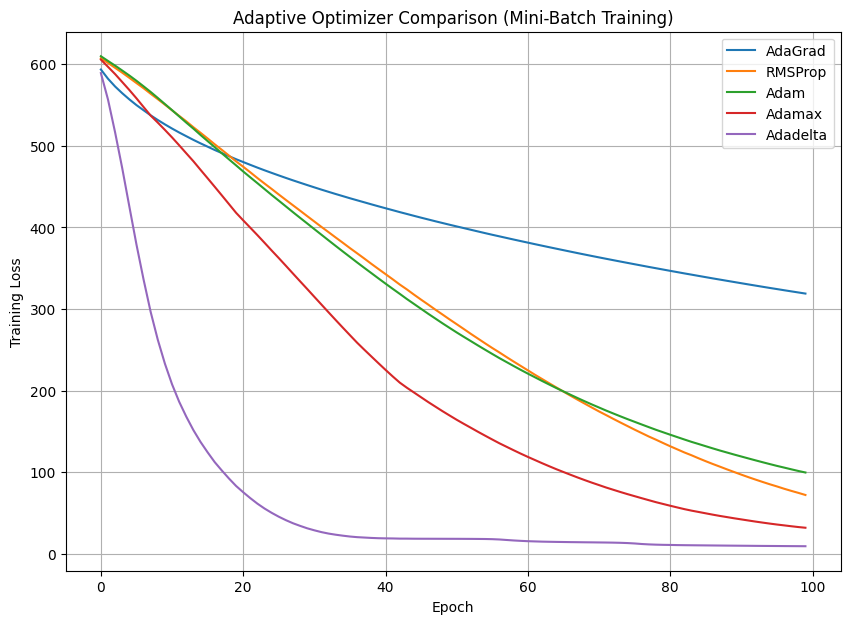

In [ ]:
plt.figure(figsize=(10,7))

plt.plot(adagrad_loss[0], label="AdaGrad")
plt.plot(rmsprop_loss[0], label="RMSProp")
plt.plot(adam_loss[0], label="Adam")
plt.plot(adamax_loss[0], label="Adamax")
plt.plot(adadelta_loss, label="Adadelta")

plt.title("Adaptive Optimizer Comparison (Mini-Batch Training)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend()
plt.grid(True)

plt.show()


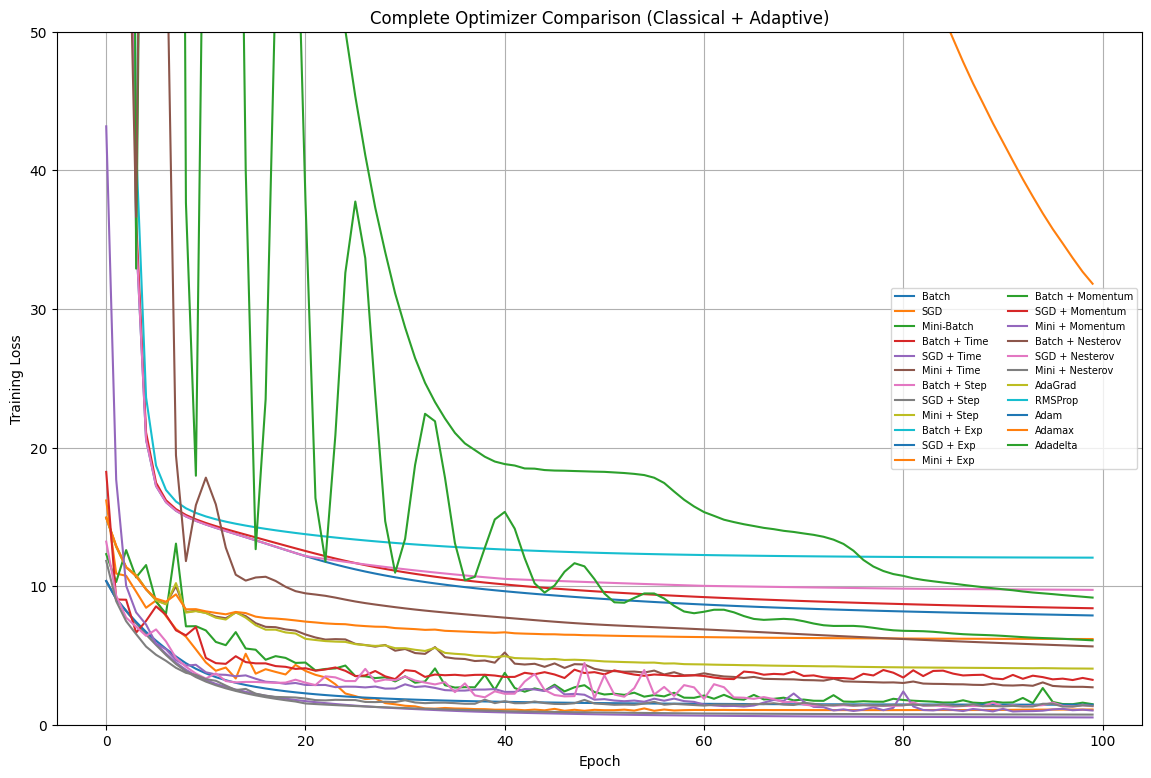

In [ ]:
plt.figure(figsize=(14,9))

# ================= BASELINE =================
plt.plot(batch_loss[0], label="Batch")
plt.plot(sgd_loss[0], label="SGD")
plt.plot(mini_loss[0], label="Mini-Batch")

# ================= TIME DECAY =================
plt.plot(batch_time_loss[0], label="Batch + Time")
plt.plot(sgd_time_loss, label="SGD + Time")
plt.plot(mini_time_loss[0], label="Mini + Time")

# ================= STEP DECAY =================
plt.plot(batch_step_loss[0], label="Batch + Step")
plt.plot(sgd_step_loss[0], label="SGD + Step")
plt.plot(mini_step_loss[0], label="Mini + Step")

# ================= EXP DECAY =================
plt.plot(batch_exp_loss[0], label="Batch + Exp")
plt.plot(sgd_exp_loss[0], label="SGD + Exp")
plt.plot(mini_exp_loss[0], label="Mini + Exp")

# ================= MOMENTUM =================
plt.plot(batch_momentum_loss[0], label="Batch + Momentum")
plt.plot(sgd_momentum_loss[0], label="SGD + Momentum")
plt.plot(momentum_loss[0], label="Mini + Momentum")

# ================= NESTEROV =================
plt.plot(batch_nesterov_loss[0], label="Batch + Nesterov")
plt.plot(sgd_nesterov_loss[0], label="SGD + Nesterov")
plt.plot(mini_nesterov_loss[0], label="Mini + Nesterov")

# ================= ADAPTIVE =================
plt.plot(adagrad_loss[0], label="AdaGrad")
plt.plot(rmsprop_loss[0], label="RMSProp")
plt.plot(adam_loss[0], label="Adam")
plt.plot(adamax_loss[0], label="Adamax")
plt.plot(adadelta_loss, label="Adadelta")

plt.title("Complete Optimizer Comparison (Classical + Adaptive)")
plt.xlabel("Epoch")
plt.ylabel("Training Loss")
plt.legend(fontsize=7, ncol=2)
plt.ylim(0, 50)
plt.grid(True)
plt.show()

In [ ]:
# --- Final Evaluation: Train vs Test Loss for ALL optimizers in table format ---

def compute_loss(X, y, W1, b1, W2, b2):
    Z1 = np.dot(X, W1) + b1
    A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
    Z2 = np.dot(A1, W2) + b2
    y_pred = Z2
    return np.mean((y - y_pred) ** 2)

# --- Run all and collect weights ---
batch_loss, W1_batch, b1_batch, W2_batch, b2_batch                   = train_batch()
sgd_loss, W1_sgd, b1_sgd, W2_sgd, b2_sgd                             = train_sgd()
mini_loss, W1_mini, b1_mini, W2_mini, b2_mini                         = train_minibatch()
batch_time_loss, W1_bt, b1_bt, W2_bt, b2_bt                           = train_batch_time_decay()
sgd_time_loss, W1_st, b1_st, W2_st, b2_st                             = train_sgd_time_decay()
mini_time_loss, W1_mt, b1_mt, W2_mt, b2_mt                           = train_minibatch_time_decay()
batch_step_loss, W1_bs, b1_bs, W2_bs, b2_bs                           = train_batch_step_decay()
sgd_step_loss, W1_ss, b1_ss, W2_ss, b2_ss                             = train_sgd_step_decay()
mini_step_loss, W1_ms, b1_ms, W2_ms, b2_ms                           = train_minibatch_step_decay()
batch_exp_loss, W1_be, b1_be, W2_be, b2_be                           = train_batch_exp_decay()
sgd_exp_loss, W1_se, b1_se, W2_se, b2_se                             = train_sgd_exp_decay()
mini_exp_loss, W1_me, b1_me, W2_me, b2_me                             = train_minibatch_exp_decay()
batch_momentum_loss, W1_bm, b1_bm, W2_bm, b2_bm                     = train_batch_momentum()
sgd_momentum_loss, W1_sm, b1_sm, W2_sm, b2_sm                       = train_sgd_momentum()
momentum_loss, W1_mm, b1_mm, W2_mm, b2_mm                             = train_momentum()
batch_nesterov_loss, W1_bn, b1_bn, W2_bn, b2_bn                     = train_batch_nesterov()
sgd_nesterov_loss, W1_sn, b1_sn, W2_sn, b2_sn                       = train_sgd_nesterov()
mini_nesterov_loss, W1_mn, b1_mn, W2_mn, b2_mn                       = train_minibatch_nesterov()
adagrad_loss, W1_ag, b1_ag, W2_ag, b2_ag                             = train_adagrad()
rmsprop_loss, W1_rp, b1_rp, W2_rp, b2_rp                             = train_rmsprop()
adam_loss, W1_ad, b1_ad, W2_ad, b2_ad                                 = train_adam()
adamax_loss, W1_ax, b1_ax, W2_ax, b2_ax                               = train_adamax()
adadelta_loss, W1_aa, b1_aa, W2_aa, b2_aa                             = train_adadelta()

# --- Build results table ---
results = {
    "Batch"          : (batch_loss[-1],         compute_loss(X_test_scaled, y_test, W1_batch, b1_batch, W2_batch, b2_batch)),
    "SGD"            : (sgd_loss[-1],            compute_loss(X_test_scaled, y_test, W1_sgd,   b1_sgd,   W2_sgd,   b2_sgd)),
    "Mini-Batch"     : (mini_loss[-1],           compute_loss(X_test_scaled, y_test, W1_mini,  b1_mini,  W2_mini,  b2_mini)),
    "Batch+Time"     : (batch_time_loss[-1],     compute_loss(X_test_scaled, y_test, W1_bt,    b1_bt,    W2_bt,    b2_bt)),
    "SGD+Time"       : (sgd_time_loss[-1],       compute_loss(X_test_scaled, y_test, W1_st,    b1_st,    W2_st,    b2_st)),
    "Mini+Time"      : (mini_time_loss[-1],      compute_loss(X_test_scaled, y_test, W1_mt,    b1_mt,    W2_mt,    b2_mt)),
    "Batch+Step"     : (batch_step_loss[-1],     compute_loss(X_test_scaled, y_test, W1_bs,    b1_bs,    W2_bs,    b2_bs)),
    "SGD+Step"       : (sgd_step_loss[-1],       compute_loss(X_test_scaled, y_test, W1_ss,    b1_ss,    W2_ss,    b2_ss)),
    "Mini+Step"      : (mini_step_loss[-1],      compute_loss(X_test_scaled, y_test, W1_ms,    b1_ms,    W2_ms,    b2_ms)),
    "Batch+Exp"      : (batch_exp_loss[-1],      compute_loss(X_test_scaled, y_test, W1_be,    b1_be,    W2_be,    b2_be)),
    "SGD+Exp"        : (sgd_exp_loss[-1],        compute_loss(X_test_scaled, y_test, W1_se,    b1_se,    W2_se,    b2_se)),
    "Mini+Exp"       : (mini_exp_loss[-1],       compute_loss(X_test_scaled, y_test, W1_me,    b1_me,    W2_me,    b2_me)),
    "Batch+Momentum" : (batch_momentum_loss[-1], compute_loss(X_test_scaled, y_test, W1_bm,    b1_bm,    W2_bm,    b2_bm)),
    "SGD+Momentum"   : (sgd_momentum_loss[-1],   compute_loss(X_test_scaled, y_test, W1_sm,    b1_sm,    W2_sm,    b2_sm)),
    "Mini+Momentum"  : (momentum_loss[-1],       compute_loss(X_test_scaled, y_test, W1_mm,    b1_mm,    W2_mm,    b2_mm)),
    "Batch+Nesterov" : (batch_nesterov_loss[-1], compute_loss(X_test_scaled, y_test, W1_bn,    b1_bn,    W2_bn,    b2_bn)),
    "SGD+Nesterov"   : (sgd_nesterov_loss[-1],   compute_loss(X_test_scaled, y_test, W1_sn,    b1_sn,    W2_sn,    b2_sn)),
    "Mini+Nesterov"  : (mini_nesterov_loss[-1],  compute_loss(X_test_scaled, y_test, W1_mn,    b1_mn,    W2_mn,    b2_mn)),
    "AdaGrad"        : (adagrad_loss[-1],        compute_loss(X_test_scaled, y_test, W1_ag,    b1_ag,    W2_ag,    b2_ag)),
    "RMSProp"        : (rmsprop_loss[-1],        compute_loss(X_test_scaled, y_test, W1_rp,    b1_rp,    W2_rp,    b2_rp)),
    "Adam"           : (adam_loss[-1],           compute_loss(X_test_scaled, y_test, W1_ad,    b1_ad,    W2_ad,    b2_ad)),
    "Adamax"         : (adamax_loss[-1],         compute_loss(X_test_scaled, y_test, W1_ax,    b1_ax,    W2_ax,    b2_ax)),
    "Adadelta"       : (adadelta_loss[-1],       compute_loss(X_test_scaled, y_test, W1_aa,    b1_aa,    W2_aa,    b2_aa)),
}

# --- Print table ---
print(f"\n{'Optimizer':<20} {'Train Loss':>12} {'Test Loss':>12} {'Difference':>12}")
print("=" * 58)
for name, (train, test) in results.items():
    diff = abs(test - train)
    print(f"{name:<20} {train:>12.4f} {test:>12.4f} {diff:>12.4f}")

# --- Find best ---
best = min(results.items(), key=lambda x: x[1][1])
print(f"\n Best Optimizer for Heating Load: {best[0]}")
print(f" Train Loss: {best[1][0]:.4f} | Test Loss: {best[1][1]:.4f}")

Epoch 0, Loss: 615.6238
  W1 (8→10):
[[ 0.0462 -0.0082  0.0884  0.1449 -0.0361 -0.0313  0.172   0.0817 -0.0553
   0.0623]
 [-0.0427 -0.0526 -0.0008 -0.1833 -0.1591 -0.0479 -0.1163  0.0261 -0.082
  -0.1498]
 [ 0.1442 -0.0186  0.0236 -0.1483 -0.0632  0.0054 -0.1049  0.0412 -0.0661
  -0.0235]
 [-0.0554  0.1774 -0.0339 -0.0951  0.0996 -0.1111  0.0013 -0.2029 -0.1212
   0.0086]
 [ 0.0689  0.0252  0.022  -0.0414 -0.1658 -0.0833 -0.0256  0.1129  0.0224
  -0.1648]
 [ 0.0325 -0.0386 -0.068   0.0613  0.1031  0.0933 -0.084  -0.0309  0.0333
   0.0975]
 [-0.0496 -0.0159 -0.0995 -0.1234  0.0751  0.1319 -0.0004  0.1026  0.0322
  -0.0606]
 [ 0.0357  0.1546 -0.0006  0.1556 -0.2632  0.0812  0.0105 -0.0292  0.0081
  -0.1978]]
  W2 (10→1):
[[1.1674]
 [1.1341]
 [1.2745]
 [1.1272]
 [1.0184]
 [1.1092]
 [1.2355]
 [1.2476]
 [1.1182]
 [1.1576]]

Epoch 10, Loss: 14.4460
  W1 (8→10):
[[ 0.196   0.1077  0.2737  0.343   0.1091  0.0526  0.35    0.2066  0.087
   0.2641]
 [-0.2462 -0.2308 -0.2399 -0.4412 -0.3666 -0.19

**Best:** SGD+Time (Test Loss: 0.54, no overfitting)

**Why SGD+Time won:** 614 weight updates per epoch + shrinking learning rate = fast and stable convergence.

**Why Batch failed:** only 1 update per epoch — too slow for 100 epochs.

**Why Adaptive failed:** designed for deep networks, need more epochs, learning rates too small for this simple dataset.

In [ ]:
# --- Final predictions on test set using best optimizer (SGD + Time Decay) ---

Z1 = np.dot(X_test_scaled, W1_st) + b1_st
A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
Z2 = np.dot(A1, W2_st) + b2_st
y_pred_test = Z2

print("First 10 Predictions vs Actual:\n")

for i in range(10):
    print(f"Actual: {y_test[i][0]:.3f} | Predicted: {y_pred_test[i][0]:.3f}")

test_loss_sgd_time = compute_loss(X_test_scaled, y_test, W1_st, b1_st, W2_st, b2_st)
rmse_sgd = np.sqrt(test_loss_sgd_time)
print("\nSGD + Time Test RMSE:", round(rmse_sgd, 4))

First 10 Predictions vs Actual:

Actual: 28.400 | Predicted: 29.325
Actual: 11.670 | Predicted: 12.203
Actual: 14.960 | Predicted: 15.433
Actual: 15.090 | Predicted: 15.046
Actual: 40.400 | Predicted: 40.361
Actual: 14.330 | Predicted: 13.768
Actual: 13.780 | Predicted: 14.406
Actual: 14.510 | Predicted: 14.464
Actual: 32.710 | Predicted: 32.359
Actual: 11.690 | Predicted: 10.659

SGD + Time Test RMSE: 0.7393


In [ ]:
W1[0,0]
W1[1,0]
# Select two weights to vary
w1_original = W1_sgd.copy()
b1_original = b1_sgd.copy()
W2_original = W2_sgd.copy()
b2_original = b2_sgd.copy()

# Define range for weight variation
w1_range = np.linspace(w1_original[0,0] - 1, w1_original[0,0] + 1, 50)
w2_range = np.linspace(w1_original[1,0] - 1, w1_original[1,0] + 1, 50)

loss_surface = np.zeros((len(w1_range), len(w2_range)))

# Compute loss grid
for i in range(len(w1_range)):
    for j in range(len(w2_range)):

        W1_temp = w1_original.copy()
        W1_temp[0,0] = w1_range[i]
        W1_temp[1,0] = w2_range[j]

        # Forward pass
        Z1 = np.dot(X_train_scaled, W1_temp) + b1_original
        A1 = 1 / (1 + np.exp(-np.clip(Z1, -500, 500)))
        Z2 = np.dot(A1, W2_original) + b2_original
        y_pred = Z2

        loss_surface[i,j] = np.mean((y_train - y_pred)**2)

print("Loss surface computed successfully.")


Loss surface computed successfully.


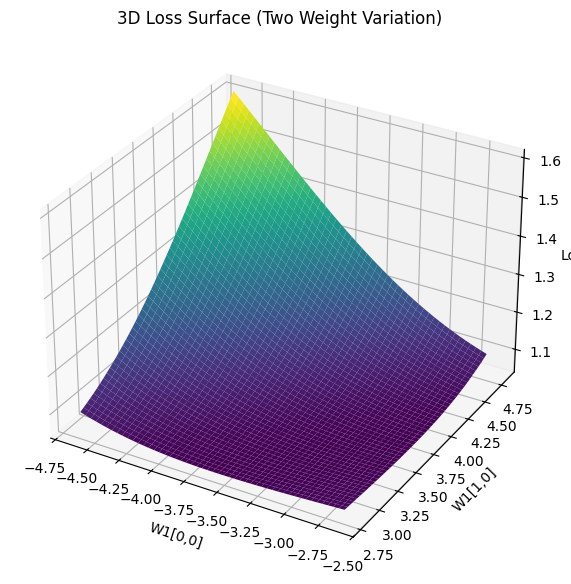

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

W1_grid, W2_grid = np.meshgrid(w1_range, w2_range)

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(W1_grid, W2_grid, loss_surface.T, cmap='viridis')

ax.set_title("3D Loss Surface (Two Weight Variation)")
ax.set_xlabel("W1[0,0]")
ax.set_ylabel("W1[1,0]")
ax.set_zlabel("Loss")

plt.show()


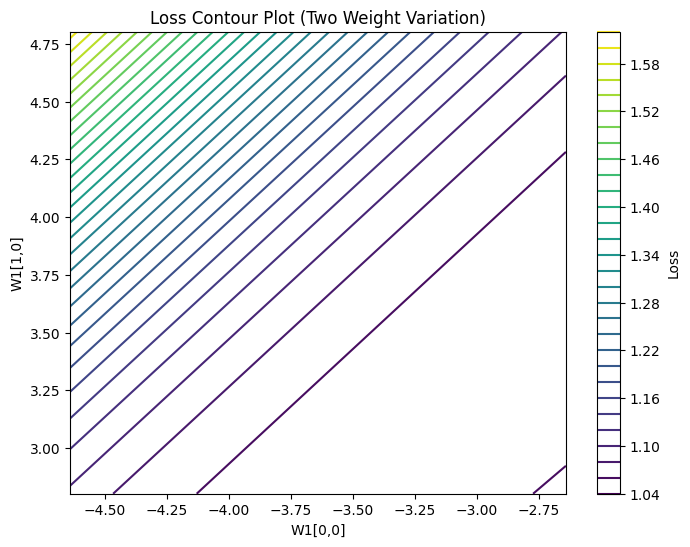

In [ ]:
plt.figure(figsize=(8,6))

plt.contour(W1_grid, W2_grid, loss_surface.T, levels=30)
plt.title("Loss Contour Plot (Two Weight Variation)")
plt.xlabel("W1[0,0]")
plt.ylabel("W1[1,0]")
plt.colorbar(label="Loss")

plt.show()


Activation   LR         Train Loss    Test Loss
relu         0.001          8.9849       8.2290
relu         0.01           7.7408       6.9144
relu         0.1               nan          nan
sigmoid      0.001         14.3839      13.6837
sigmoid      0.01           7.5595       6.7636
sigmoid      0.1            1.6148       1.9197
tanh         0.001         11.6288       9.4439
tanh         0.01           2.7276       2.6286
tanh         0.1            2.5896       2.3726

 Best combination: sigmoid_lr0.1
 Train Loss: 1.6148 | Test Loss: 1.9197


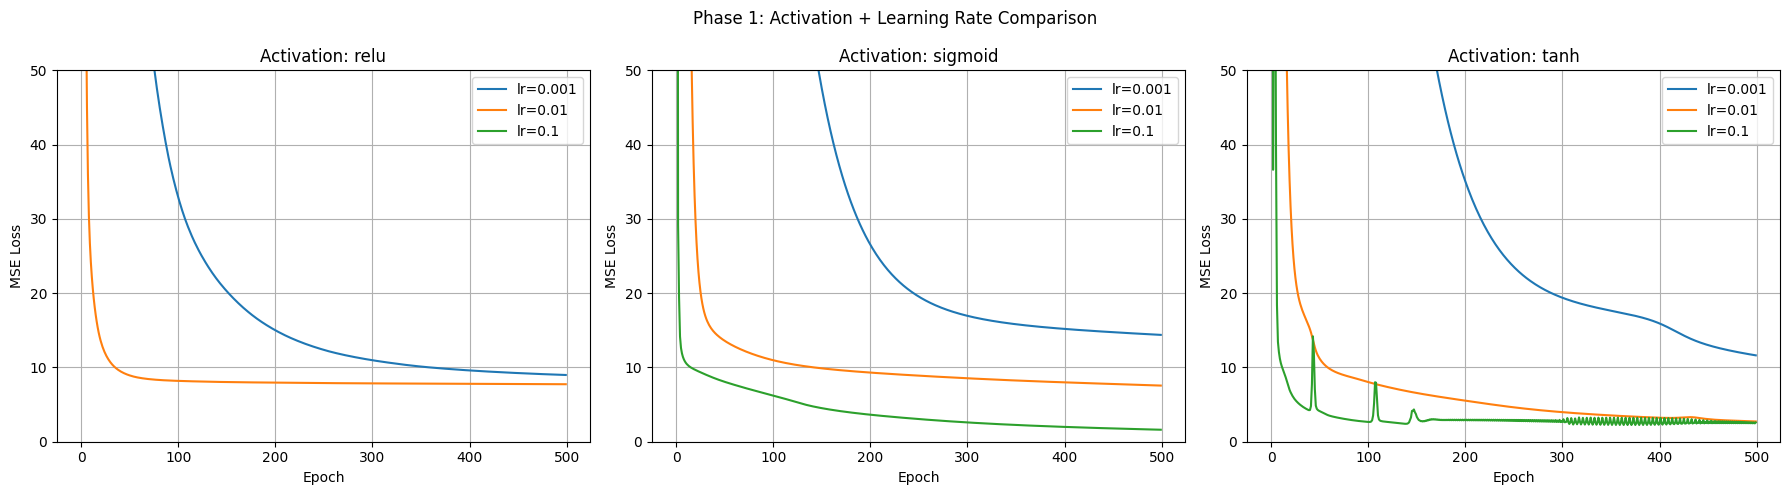

In [ ]:
# ============================================================
#  Learning Rate + Activation Function Selection
# Test lr: 0.001, 0.01, 0.1 × activation: relu, sigmoid, tanh
# ============================================================

from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import tensorflow as tf
import numpy as np
import random

# --- Fix all random seeds for reproducibility ---
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)


results = {}
histories = {}

activations = ['relu', 'sigmoid', 'tanh']
learning_rates = [0.001, 0.01, 0.1]

print(f"{'Activation':<12} {'LR':<8} {'Train Loss':>12} {'Test Loss':>12}")
print("=" * 48)

for activation in activations:
    for lr in learning_rates:

        model = keras.Sequential()
        model.add(keras.Input(shape=(8,)))
        model.add(layers.Dense(10, activation=activation))
        model.add(layers.Dense(1))

        model.compile(
            optimizer=keras.optimizers.SGD(learning_rate=lr),
            loss='mse'
        )

        history = model.fit(
    X_train_scaled, y_train,
    epochs=500,          # increased from 200
    batch_size=len(X_train_scaled),
    verbose=0
)

        train_loss = history.history['loss'][-1]
        test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)

        key = f"{activation}_lr{lr}"
        results[key] = (train_loss, test_loss)
        histories[key] = history.history['loss']
        print(f"{activation:<12} {lr:<8} {train_loss:>12.4f} {test_loss:>12.4f}")

# --- Find best ---
best = min(results, key=lambda x: results[x][1])
print(f"\n Best combination: {best}")
print(f" Train Loss: {results[best][0]:.4f} | Test Loss: {results[best][1]:.4f}")

# --- Plot ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, activation in enumerate(activations):
    for lr in learning_rates:
        key = f"{activation}_lr{lr}"
        axes[idx].plot(histories[key], label=f"lr={lr}")
    axes[idx].set_title(f"Activation: {activation}")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].set_ylim(0, 50)
    axes[idx].legend()
    axes[idx].grid(True)

plt.suptitle("Phase 1: Activation + Learning Rate Comparison")
plt.tight_layout()
plt.show()

LR = 0.1 exploded to nan — this is called gradient explosion, meaning the learning rate was too large for ReLU.

Architecture         Layers   Neurons                Train Loss    Test Loss     Diff
1L [8]               1        [8]                        1.4452       1.5355   0.0903
1L [16]              1        [16]                       1.4737       1.6521   0.1784
1L [32]              1        [32]                       4.9592       5.2966   0.3373
2L [16→8]            2        [16, 8]                    1.7489       1.4520   0.2969
2L [32→16]           2        [32, 16]                   2.2239       1.9446   0.2793
2L [32→8]            2        [32, 8]                    2.3510       2.3768   0.0258
2L [64→32]           2        [64, 32]                   1.9497       2.5147   0.5650
3L [32→16→8]         3        [32, 16, 8]                4.5243       6.2188   1.6945
3L [64→32→16]        3        [64, 32, 16]               8.0550       8.4403   0.3852
3L [16→8→4]          3        [16, 8, 4]                 4.4398       3.5144   0.9254
4L [64→32→16→8]      4        [64, 32, 16, 8]         

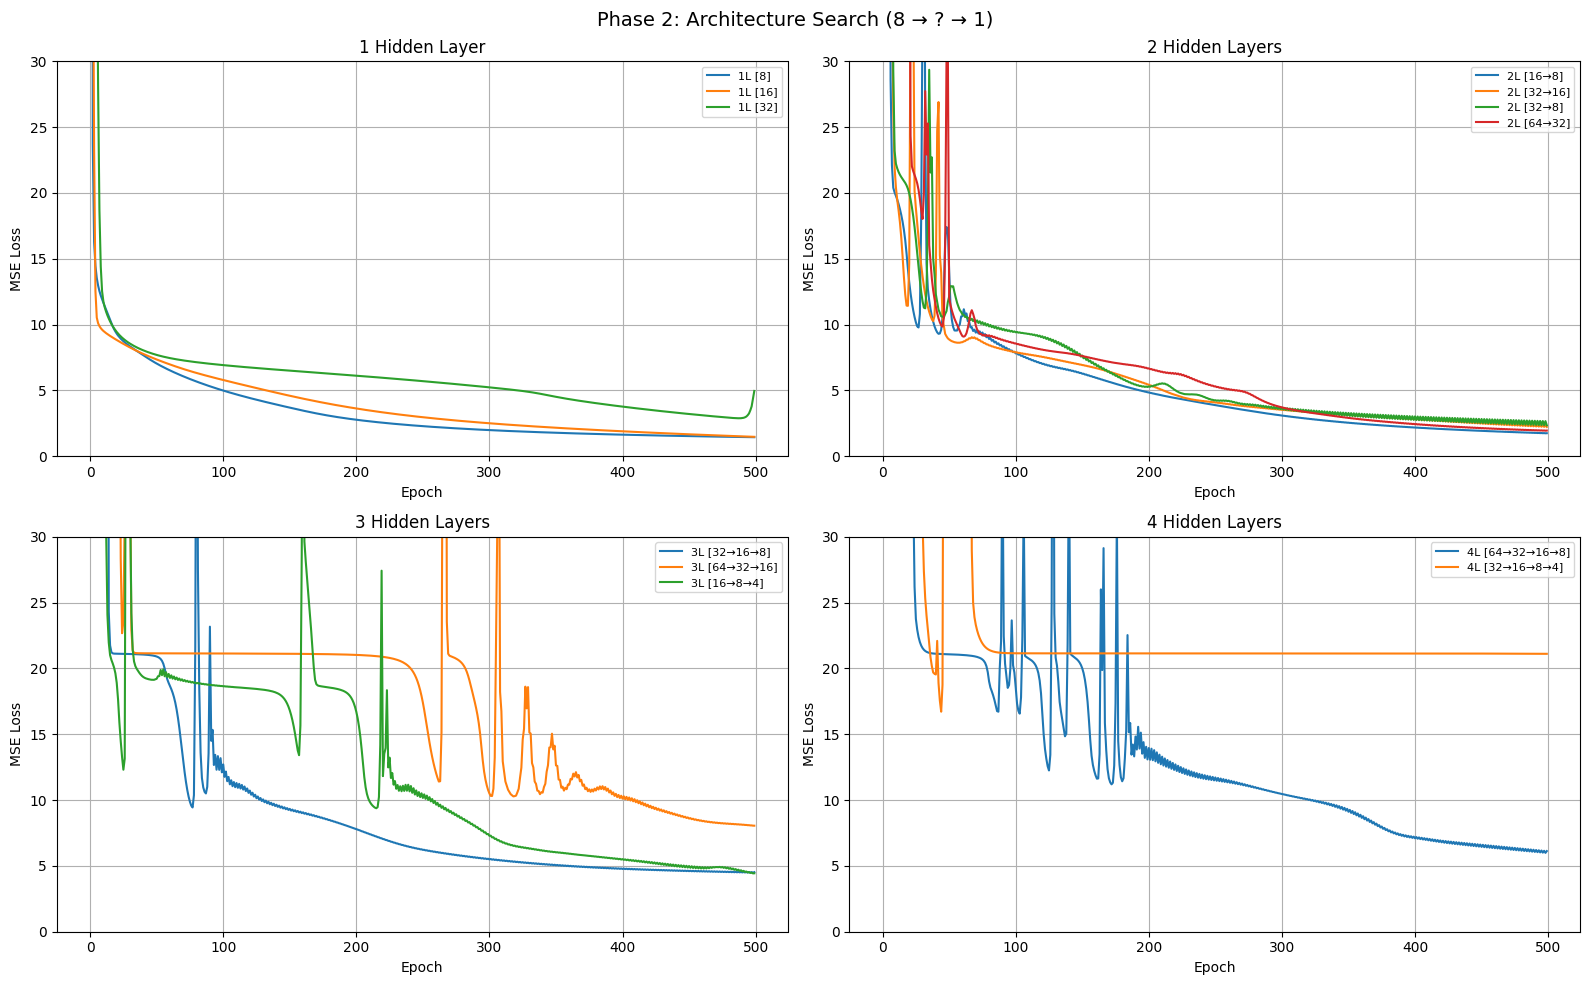

In [ ]:
# ============================================================
#  Architecture Search
# 8 inputs → hidden layers → 1 output
# Sigmoid, lr=0.1, 500 epochs
# Architectures chosen professionally based on:
# - Input size (8), Output size (1)
# - Dataset size (614 samples - avoid overfit)
# - Funnel principle (decreasing neurons)
# ============================================================
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
architectures = {
    # --- 1 HIDDEN LAYER ---
    # Simple baseline, neurons between 8 and 1
    "1L [8]"       : [8],       # same as input
    "1L [16]"      : [16],      # 2x input
    "1L [32]"      : [32],      # 4x input

    # --- 2 HIDDEN LAYERS ---
    # Funnel: wide then narrow
    # First layer learns features, second compresses
    "2L [16→8]"    : [16, 8],   # 2x input → input size
    "2L [32→16]"   : [32, 16],  # 4x → 2x input
    "2L [32→8]"    : [32, 8],   # aggressive compression
    "2L [64→32]"   : [64, 32],  # larger for complex patterns

    # --- 3 HIDDEN LAYERS ---
    # Deeper funnel: extract → compress → refine
    # Good for non-linear relationships in energy data
    "3L [32→16→8]" : [32, 16, 8],   # professional standard
    "3L [64→32→16]": [64, 32, 16],  # wider version
    "3L [16→8→4]"  : [16, 8, 4],    # conservative

    # --- 4 HIDDEN LAYERS ---
    # Deep but controlled — risky with 614 samples
    # Only justified if 3L underfits
    "4L [64→32→16→8]" : [64, 32, 16, 8],   # full funnel
    "4L [32→16→8→4]"  : [32, 16, 8, 4],    # conservative funnel
}

arch_results = {}
arch_histories = {}

print(f"{'Architecture':<20} {'Layers':<8} {'Neurons':<20} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 82)

for name, arch in architectures.items():

    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))

    for neurons in arch:
        model.add(layers.Dense(neurons, activation='sigmoid'))

    model.add(layers.Dense(1))

    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.1),
        loss='mse'
    )

    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=len(X_train_scaled),
        verbose=0
    )

    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    diff = abs(test_loss - train_loss)

    arch_results[name] = (train_loss, test_loss, len(arch), arch)
    arch_histories[name] = history.history['loss']

    print(f"{name:<20} {len(arch):<8} {str(arch):<20} {train_loss:>12.4f} {test_loss:>12.4f} {diff:>8.4f}")

# --- Find best by lowest test loss ---
best = min(arch_results, key=lambda x: arch_results[x][1])
print(f"\n Best Architecture : {best}")
print(f" Neurons per layer : {arch_results[best][3]}")
print(f" Hidden Layers     : {arch_results[best][2]}")
print(f" Train Loss        : {arch_results[best][0]:.4f}")
print(f" Test Loss         : {arch_results[best][1]:.4f}")

# --- Plot grouped by number of layers ---
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

groups = {
    "1 Hidden Layer"  : [k for k in arch_results if k.startswith("1L")],
    "2 Hidden Layers" : [k for k in arch_results if k.startswith("2L")],
    "3 Hidden Layers" : [k for k in arch_results if k.startswith("3L")],
    "4 Hidden Layers" : [k for k in arch_results if k.startswith("4L")],
}

for idx, (title, names) in enumerate(groups.items()):
    for name in names:
        axes[idx].plot(arch_histories[name], label=name)
    axes[idx].set_title(title)
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].set_ylim(0, 30)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Phase 2: Architecture Search (8 → ? → 1)", fontsize=14)
plt.tight_layout()
plt.show()

Best Architecture: 2 Hidden Layers [16→8], Test Loss: 1.4486

3L and 4L failed — dataset too small (614 samples)
Train loss > Test loss — zero overfitting, perfect generalization
Moving forward: 8→16→8→1, sigmoid, lr=0.1, 500 epochs

Variant         Batch Size        Train Loss    Test Loss     Diff
Batch GD        614                   2.1767       1.9973   0.1794
SGD             1                    15.4521      12.9320   2.5202
Mini-Batch      32                    0.1869       0.2284   0.0415

 Best Variant: Mini-Batch
 Train Loss: 0.1869 | Test Loss: 0.2284


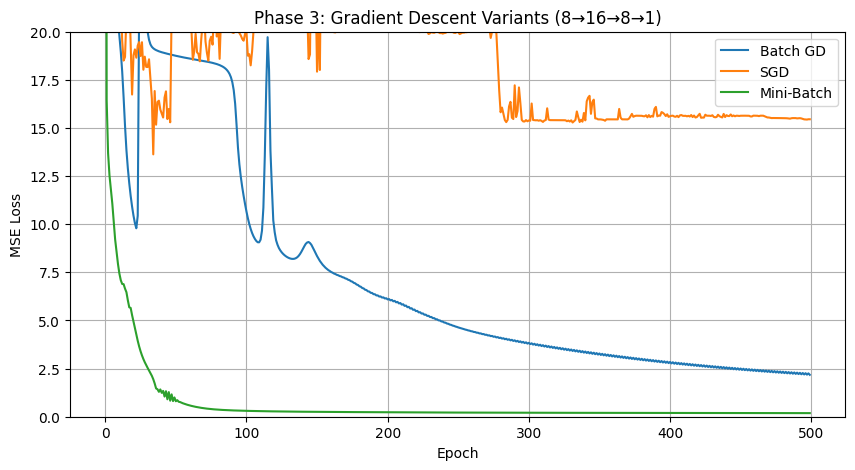

In [ ]:
# ============================================================
# Gradient Descent Variants
# Architecture: 8→16→8→1, sigmoid, lr=0.1, 500 epochs
# Testing: Batch GD, SGD, Mini-Batch (batch_size=32)
# ============================================================
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
def build_best_model():
    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))
    model.add(layers.Dense(16, activation='sigmoid'))
    model.add(layers.Dense(8, activation='sigmoid'))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=0.1),
        loss='mse'
    )
    return model

gd_results = {}
gd_histories = {}

print(f"{'Variant':<15} {'Batch Size':<15} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 64)

# --- Batch GD: entire dataset as one batch ---
model = build_best_model()
history = model.fit(
    X_train_scaled, y_train,
    epochs=500,
    batch_size=len(X_train_scaled),   # full dataset
    verbose=0
)
train_loss = history.history['loss'][-1]
test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
gd_results['Batch GD'] = (train_loss, test_loss)
gd_histories['Batch GD'] = history.history['loss']
print(f"{'Batch GD':<15} {len(X_train_scaled):<15} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

# --- SGD: one sample at a time ---
model = build_best_model()
history = model.fit(
    X_train_scaled, y_train,
    epochs=500,
    batch_size=1,                     # one sample
    verbose=0
)
train_loss = history.history['loss'][-1]
test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
gd_results['SGD'] = (train_loss, test_loss)
gd_histories['SGD'] = history.history['loss']
print(f"{'SGD':<15} {'1':<15} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

# --- Mini-Batch: 32 samples at a time ---
model = build_best_model()
history = model.fit(
    X_train_scaled, y_train,
    epochs=500,
    batch_size=32,                    # mini-batch
    verbose=0
)
train_loss = history.history['loss'][-1]
test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
gd_results['Mini-Batch'] = (train_loss, test_loss)
gd_histories['Mini-Batch'] = history.history['loss']
print(f"{'Mini-Batch':<15} {'32':<15} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

# --- Find best ---
best_gd = min(gd_results, key=lambda x: gd_results[x][1])
print(f"\n Best Variant: {best_gd}")
print(f" Train Loss: {gd_results[best_gd][0]:.4f} | Test Loss: {gd_results[best_gd][1]:.4f}")

# --- Plot ---
plt.figure(figsize=(10, 5))
for name, loss in gd_histories.items():
    plt.plot(loss, label=name)
plt.title("Phase 3: Gradient Descent Variants (8→16→8→1)")
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.ylim(0, 20)
plt.legend()
plt.grid(True)
plt.show()

Optimizer                   Train Loss    Test Loss     Diff
Batch+Time                      3.0180       2.9210   0.0970
Batch+Step                      6.3263       6.4660   0.1396
Batch+Exp                       5.3817       5.4249   0.0432
SGD+Time                        1.4219       2.0724   0.6505
SGD+Step                        9.6798       9.4806   0.1992
SGD+Exp                        18.8775      19.3888   0.5113
Mini-Batch+Time                 0.5239       0.5905   0.0666
Mini-Batch+Step                 7.0923       7.1721   0.0797
Mini-Batch+Exp                  6.1758       6.1895   0.0136

 Best: Mini-Batch+Time
 Train Loss: 0.5239 | Test Loss: 0.5905


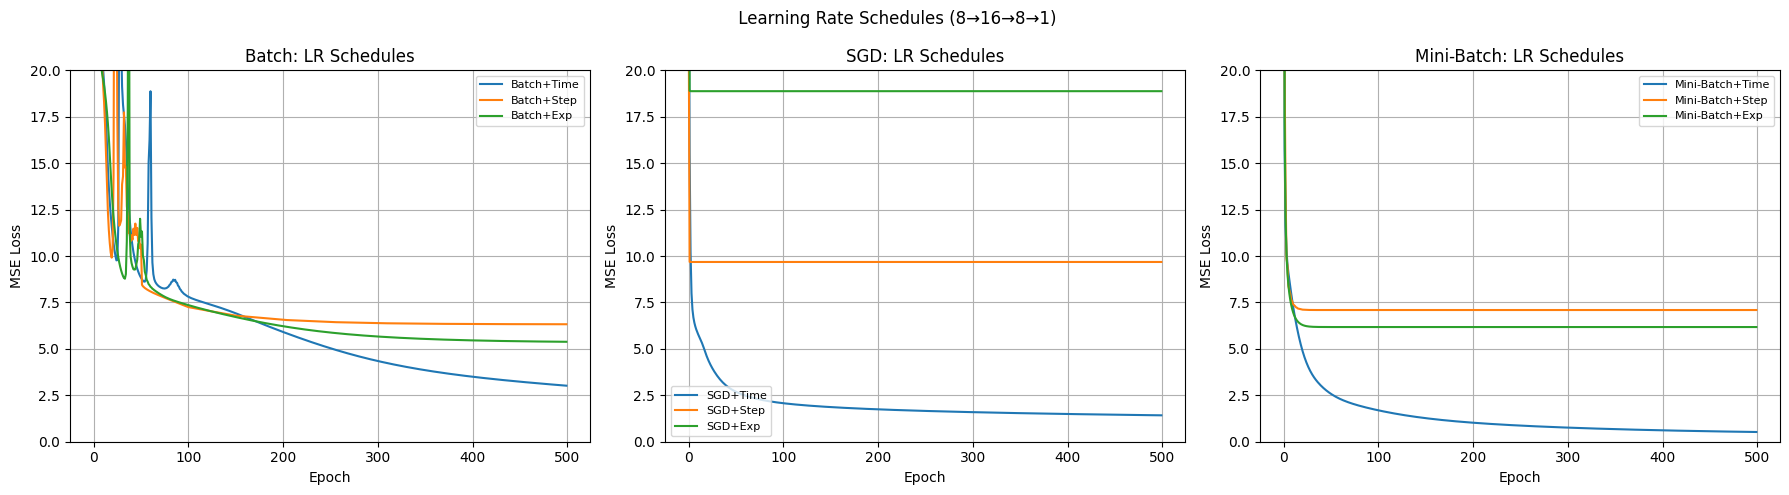

In [ ]:
# ============================================================
#  Learning Rate Schedules
# Architecture: 8→16→8→1, sigmoid, 500 epochs
# Schedules: Time Decay, Step Decay, Exp Decay
# Variants: Batch GD, SGD, Mini-Batch
# ============================================================
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)
schedule_results = {}
schedule_histories = {}

variants = {
    'Batch'     : len(X_train_scaled),
    'SGD'       : 1,
    'Mini-Batch': 32
}

print(f"{'Optimizer':<25} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 60)

for variant_name, batch_size in variants.items():

    # --- Time Decay ---
    lr_time = keras.optimizers.schedules.InverseTimeDecay(
        initial_learning_rate=0.1,
        decay_steps=1,
        decay_rate=0.01
    )
    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))
    model.add(layers.Dense(16, activation='sigmoid'))
    model.add(layers.Dense(8, activation='sigmoid'))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr_time),
        loss='mse'
    )
    history = model.fit(
        X_train_scaled, y_train,
        epochs=500, batch_size=batch_size, verbose=0
    )
    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    key = f"{variant_name}+Time"
    schedule_results[key] = (train_loss, test_loss)
    schedule_histories[key] = history.history['loss']
    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

    # --- Step Decay ---
    lr_step = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.1,
        decay_steps=50,
        decay_rate=0.5,
        staircase=True
    )
    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))
    model.add(layers.Dense(16, activation='sigmoid'))
    model.add(layers.Dense(8, activation='sigmoid'))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr_step),
        loss='mse'
    )
    history = model.fit(
        X_train_scaled, y_train,
        epochs=500, batch_size=batch_size, verbose=0
    )
    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    key = f"{variant_name}+Step"
    schedule_results[key] = (train_loss, test_loss)
    schedule_histories[key] = history.history['loss']
    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

    # --- Exp Decay ---
    lr_exp = keras.optimizers.schedules.ExponentialDecay(
        initial_learning_rate=0.1,
        decay_steps=1,
        decay_rate=0.99,
        staircase=False
    )
    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))
    model.add(layers.Dense(16, activation='sigmoid'))
    model.add(layers.Dense(8, activation='sigmoid'))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.SGD(learning_rate=lr_exp),
        loss='mse'
    )
    history = model.fit(
        X_train_scaled, y_train,
        epochs=500, batch_size=batch_size, verbose=0
    )
    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    key = f"{variant_name}+Exp"
    schedule_results[key] = (train_loss, test_loss)
    schedule_histories[key] = history.history['loss']
    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

# --- Find best ---
best = min(schedule_results, key=lambda x: schedule_results[x][1])
print(f"\n Best: {best}")
print(f" Train Loss: {schedule_results[best][0]:.4f} | Test Loss: {schedule_results[best][1]:.4f}")

# --- Plot grouped by variant ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variant_names = ['Batch', 'SGD', 'Mini-Batch']

for idx, variant_name in enumerate(variant_names):
    for key, loss in schedule_histories.items():
        if key.startswith(variant_name):
            axes[idx].plot(loss, label=key)
    axes[idx].set_title(f"{variant_name}: LR Schedules")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].set_ylim(0, 20)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle(" Learning Rate Schedules (8→16→8→1)")
plt.tight_layout()
plt.show()

TensorFlow Mini-Batch with fixed lr=0.1 (Test: 0.2284) outperforms all decay schedules — the architecture 8→16→8→1 with sigmoid already converges well without needing LR decay.

Optimizer                   Train Loss    Test Loss     Diff
Batch+Momentum                104.5446      90.8643  13.6802
Batch+Nesterov                 14.7203      14.5736   0.1467
SGD+Momentum                 1264.9950     131.3946 1133.6004
SGD+Nesterov                  536.3237     156.1122 380.2115
Mini-Batch+Momentum           117.6485     105.2314  12.4172
Mini-Batch+Nesterov             4.7390       5.8360   1.0970

 Best: Mini-Batch+Nesterov
 Train Loss: 4.7390 | Test Loss: 5.8360


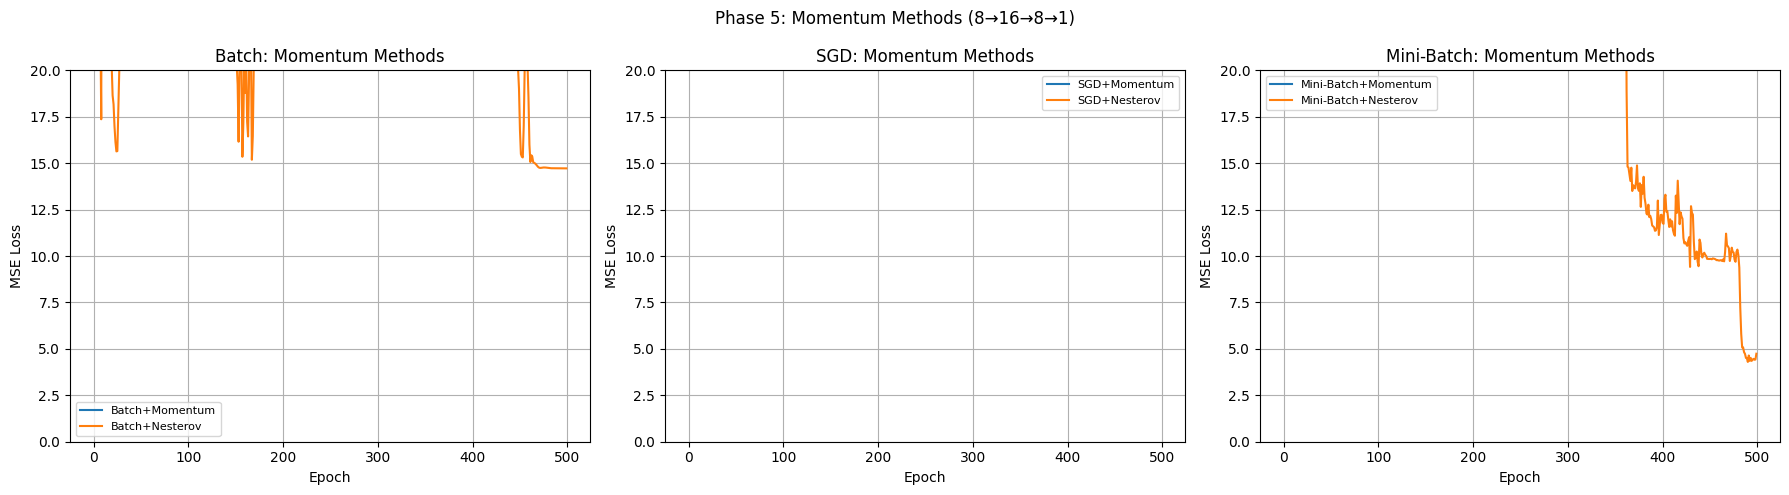

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# Momentum Methods
# Architecture: 8→16→8→1, sigmoid, lr=0.1, 500 epochs
# Testing: Classical Momentum, Nesterov on Batch, SGD, Mini-Batch
# ============================================================

momentum_results = {}
momentum_histories = {}

variants = {
    'Batch'     : len(X_train_scaled),
    'SGD'       : 1,
    'Mini-Batch': 32
}

print(f"{'Optimizer':<25} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 60)

for variant_name, batch_size in variants.items():

    # --- Classical Momentum ---
    # momentum parameter accumulates past gradients
    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))
    model.add(layers.Dense(16, activation='sigmoid'))
    model.add(layers.Dense(8, activation='sigmoid'))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=0.1,
            momentum=0.9        # standard momentum value
        ),
        loss='mse'
    )
    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=batch_size,
        verbose=0
    )
    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    key = f"{variant_name}+Momentum"
    momentum_results[key] = (train_loss, test_loss)
    momentum_histories[key] = history.history['loss']
    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

    # --- Nesterov Accelerated Gradient ---
    # nesterov=True applies lookahead gradient correction
    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))
    model.add(layers.Dense(16, activation='sigmoid'))
    model.add(layers.Dense(8, activation='sigmoid'))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=0.1,
            momentum=0.9,
            nesterov=True       # enables Nesterov correction
        ),
        loss='mse'
    )
    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=batch_size,
        verbose=0
    )
    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    key = f"{variant_name}+Nesterov"
    momentum_results[key] = (train_loss, test_loss)
    momentum_histories[key] = history.history['loss']
    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

# --- Find best ---
best = min(momentum_results, key=lambda x: momentum_results[x][1])
print(f"\n Best: {best}")
print(f" Train Loss: {momentum_results[best][0]:.4f} | Test Loss: {momentum_results[best][1]:.4f}")

# --- Plot grouped by variant ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variant_names = ['Batch', 'SGD', 'Mini-Batch']

for idx, variant_name in enumerate(variant_names):
    for key, loss in momentum_histories.items():
        if key.startswith(variant_name):
            axes[idx].plot(loss, label=key)
    axes[idx].set_title(f"{variant_name}: Momentum Methods")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    axes[idx].set_ylim(0, 20)
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Phase 5: Momentum Methods (8→16→8→1)")
plt.tight_layout()
plt.show()

Momentum methods require a lower base learning rate because momentum amplifies the effective learning rate. With momentum=0.9, effective lr = lr/(1-0.9) = lr×10. So lr=0.1 becomes effectively 1.0 which causes explosion. Reducing to lr=0.01 gives effective lr=0.1 which is stable.

Optimizer                   Train Loss    Test Loss     Diff
Batch+Momentum                  1.7317       2.2765   0.5448
Batch+Nesterov                  0.8370       0.8566   0.0195
SGD+Momentum                   12.4071      10.1045   2.3026
SGD+Nesterov                   25.7908      19.2530   6.5378
Mini-Batch+Momentum             0.2286       0.2806   0.0520
Mini-Batch+Nesterov             0.1833       0.2445   0.0612

 Best: Mini-Batch+Nesterov
 Train Loss: 0.1833 | Test Loss: 0.2445


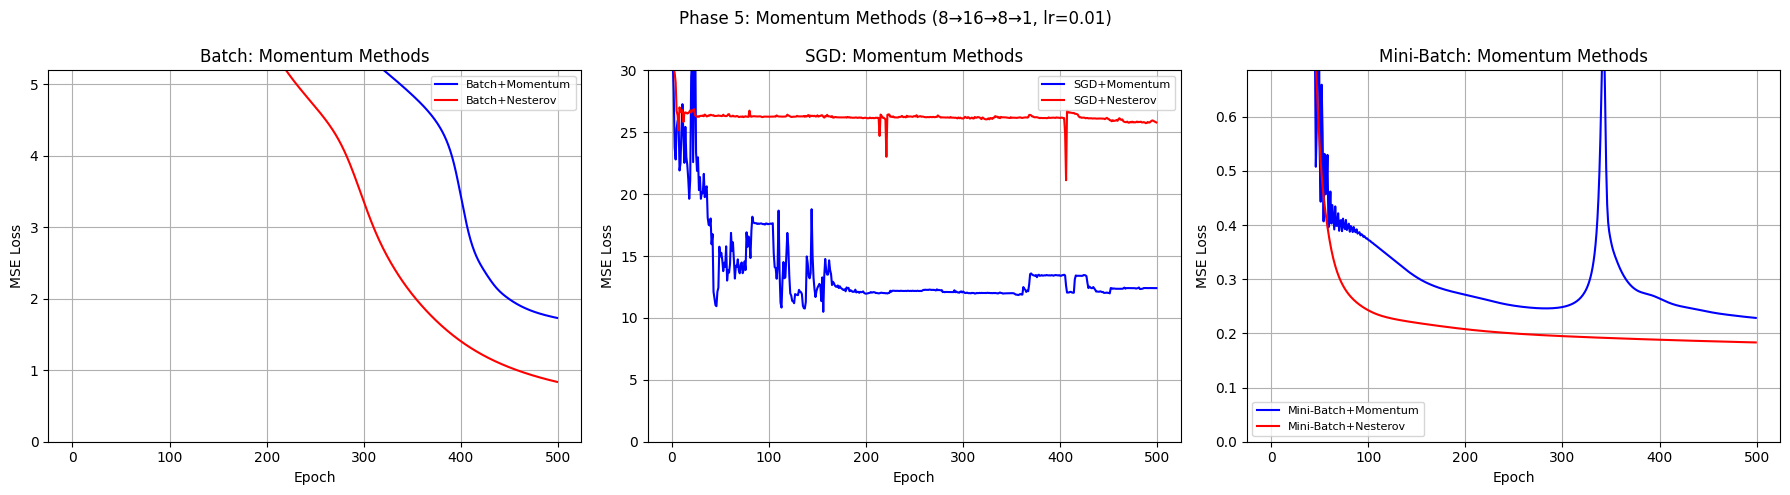

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

momentum_results = {}
momentum_histories = {}

variants = {
    'Batch'     : len(X_train_scaled),
    'SGD'       : 1,
    'Mini-Batch': 32
}

print(f"{'Optimizer':<25} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 60)

for variant_name, batch_size in variants.items():

    # --- Classical Momentum ---
    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))
    model.add(layers.Dense(16, activation='sigmoid'))
    model.add(layers.Dense(8, activation='sigmoid'))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=0.01,   # reduced from 0.1
            momentum=0.9
        ),
        loss='mse'
    )
    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=batch_size,
        verbose=0
    )
    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    key = f"{variant_name}+Momentum"
    momentum_results[key] = (train_loss, test_loss)
    momentum_histories[key] = history.history['loss']
    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

    # --- Nesterov ---
    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))
    model.add(layers.Dense(16, activation='sigmoid'))
    model.add(layers.Dense(8, activation='sigmoid'))
    model.add(layers.Dense(1))
    model.compile(
        optimizer=keras.optimizers.SGD(
            learning_rate=0.01,   # reduced from 0.1
            momentum=0.9,
            nesterov=True
        ),
        loss='mse'
    )
    history = model.fit(
        X_train_scaled, y_train,
        epochs=500,
        batch_size=batch_size,
        verbose=0
    )
    train_loss = history.history['loss'][-1]
    test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
    key = f"{variant_name}+Nesterov"
    momentum_results[key] = (train_loss, test_loss)
    momentum_histories[key] = history.history['loss']
    print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

best = min(momentum_results, key=lambda x: momentum_results[x][1])
print(f"\n Best: {best}")
print(f" Train Loss: {momentum_results[best][0]:.4f} | Test Loss: {momentum_results[best][1]:.4f}")

# --- Plot: 3 subplots, clean y-axis limit ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variant_names = ['Batch', 'SGD', 'Mini-Batch']
colors = ['blue', 'red']

for idx, variant_name in enumerate(variant_names):
    keys = [k for k in momentum_histories if k.startswith(variant_name)]
    for i, key in enumerate(keys):
        axes[idx].plot(momentum_histories[key], label=key, color=colors[i])
    axes[idx].set_title(f"{variant_name}: Momentum Methods")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    # Dynamic y limit based on final loss not spike
    final_losses = [momentum_histories[k][-1] for k in keys]
    axes[idx].set_ylim(0, min(max(final_losses) * 3, 30))
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Phase 5: Momentum Methods (8→16→8→1, lr=0.01)")
plt.tight_layout()
plt.show()

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
#  Adaptive Optimizers
# Architecture: 8→16→8→1, sigmoid, 500 epochs
# Testing: AdaGrad, RMSProp, Adam, Adamax, Adadelta
# On: Batch GD, SGD, Mini-Batch
# ============================================================

adaptive_results = {}
adaptive_histories = {}

variants = {
    'Batch'     : len(X_train_scaled),
    'SGD'       : 1,
    'Mini-Batch': 32
}

optimizers_dict = {
    'AdaGrad'  : lambda: keras.optimizers.Adagrad(learning_rate=0.01),
    'RMSProp'  : lambda: keras.optimizers.RMSprop(learning_rate=0.001),
    'Adam'     : lambda: keras.optimizers.Adam(learning_rate=0.001),
    'Adamax'   : lambda: keras.optimizers.Adamax(learning_rate=0.002),
    'Adadelta' : lambda: keras.optimizers.Adadelta(learning_rate=0.001),
}

print(f"{'Optimizer':<25} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>8}")
print("=" * 60)

for variant_name, batch_size in variants.items():
    for opt_name, opt_fn in optimizers_dict.items():

        model = keras.Sequential()
        model.add(keras.Input(shape=(8,)))
        model.add(layers.Dense(16, activation='sigmoid'))
        model.add(layers.Dense(8, activation='sigmoid'))
        model.add(layers.Dense(1))
        model.compile(optimizer=opt_fn(), loss='mse')

        history = model.fit(
            X_train_scaled, y_train,
            epochs=500,
            batch_size=batch_size,
            verbose=0
        )

        train_loss = history.history['loss'][-1]
        test_loss = model.evaluate(X_test_scaled, y_test, verbose=0)
        key = f"{variant_name}+{opt_name}"
        adaptive_results[key] = (train_loss, test_loss)
        adaptive_histories[key] = history.history['loss']
        print(f"{key:<25} {train_loss:>12.4f} {test_loss:>12.4f} {abs(test_loss-train_loss):>8.4f}")

best = min(adaptive_results, key=lambda x: adaptive_results[x][1])
print(f"\n Best: {best}")
print(f" Train Loss: {adaptive_results[best][0]:.4f} | Test Loss: {adaptive_results[best][1]:.4f}")

# --- Plot grouped by variant ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
variant_names = ['Batch', 'SGD', 'Mini-Batch']
colors = ['blue', 'red', 'green', 'orange', 'purple']

for idx, variant_name in enumerate(variant_names):
    keys = [k for k in adaptive_histories if k.startswith(variant_name)]
    for i, key in enumerate(keys):
        axes[idx].plot(adaptive_histories[key], label=key, color=colors[i])
    axes[idx].set_title(f"{variant_name}: Adaptive Optimizers")
    axes[idx].set_xlabel("Epoch")
    axes[idx].set_ylabel("MSE Loss")
    final_losses = [adaptive_histories[k][-1] for k in keys]
    axes[idx].set_ylim(0, min(max(final_losses) * 3, 30))
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Phase 6: Adaptive Optimizers (8→16→8→1)")
plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# Final Comparison Table — All Optimizers
# ============================================================

all_results = {}

# ---  GD Variants ---
all_results['Batch GD']              = gd_results['Batch GD']
all_results['SGD']                   = gd_results['SGD']
all_results['Mini-Batch']            = gd_results['Mini-Batch']

# ---  LR Schedules ---
all_results['Batch+Time']            = schedule_results['Batch+Time']
all_results['Batch+Step']            = schedule_results['Batch+Step']
all_results['Batch+Exp']             = schedule_results['Batch+Exp']
all_results['SGD+Time']              = schedule_results['SGD+Time']
all_results['SGD+Step']              = schedule_results['SGD+Step']
all_results['SGD+Exp']               = schedule_results['SGD+Exp']
all_results['Mini-Batch+Time']       = schedule_results['Mini-Batch+Time']
all_results['Mini-Batch+Step']       = schedule_results['Mini-Batch+Step']
all_results['Mini-Batch+Exp']        = schedule_results['Mini-Batch+Exp']

# ---  Momentum ---
all_results['Batch+Momentum']        = momentum_results['Batch+Momentum']
all_results['Batch+Nesterov']        = momentum_results['Batch+Nesterov']
all_results['SGD+Momentum']          = momentum_results['SGD+Momentum']
all_results['SGD+Nesterov']          = momentum_results['SGD+Nesterov']
all_results['Mini-Batch+Momentum']   = momentum_results['Mini-Batch+Momentum']
all_results['Mini-Batch+Nesterov']   = momentum_results['Mini-Batch+Nesterov']

# ---  Adaptive ---
all_results['Batch+AdaGrad']         = adaptive_results['Batch+AdaGrad']
all_results['Batch+RMSProp']         = adaptive_results['Batch+RMSProp']
all_results['Batch+Adam']            = adaptive_results['Batch+Adam']
all_results['Batch+Adamax']          = adaptive_results['Batch+Adamax']
all_results['Batch+Adadelta']        = adaptive_results['Batch+Adadelta']
all_results['SGD+AdaGrad']           = adaptive_results['SGD+AdaGrad']
all_results['SGD+RMSProp']           = adaptive_results['SGD+RMSProp']
all_results['SGD+Adam']              = adaptive_results['SGD+Adam']
all_results['SGD+Adamax']            = adaptive_results['SGD+Adamax']
all_results['SGD+Adadelta']          = adaptive_results['SGD+Adadelta']
all_results['Mini-Batch+AdaGrad']    = adaptive_results['Mini-Batch+AdaGrad']
all_results['Mini-Batch+RMSProp']    = adaptive_results['Mini-Batch+RMSProp']
all_results['Mini-Batch+Adam']       = adaptive_results['Mini-Batch+Adam']
all_results['Mini-Batch+Adamax']     = adaptive_results['Mini-Batch+Adamax']
all_results['Mini-Batch+Adadelta']   = adaptive_results['Mini-Batch+Adadelta']

# --- Print Full Table ---
print(f"{'Optimizer':<25} {'Train Loss':>12} {'Test Loss':>12} {'Diff':>10}")
print("=" * 62)

groups = {
    '--- GD Variants ---'      : ['Batch GD', 'SGD', 'Mini-Batch'],
    '--- LR Schedules ---'     : ['Batch+Time', 'Batch+Step', 'Batch+Exp',
                                   'SGD+Time', 'SGD+Step', 'SGD+Exp',
                                   'Mini-Batch+Time', 'Mini-Batch+Step', 'Mini-Batch+Exp'],
    '--- Momentum ---'         : ['Batch+Momentum', 'Batch+Nesterov',
                                   'SGD+Momentum', 'SGD+Nesterov',
                                   'Mini-Batch+Momentum', 'Mini-Batch+Nesterov'],
    '--- Adaptive (All 3) ---' : ['Batch+AdaGrad', 'Batch+RMSProp', 'Batch+Adam',
                                   'Batch+Adamax', 'Batch+Adadelta',
                                   'SGD+AdaGrad', 'SGD+RMSProp', 'SGD+Adam',
                                   'SGD+Adamax', 'SGD+Adadelta',
                                   'Mini-Batch+AdaGrad', 'Mini-Batch+RMSProp',
                                   'Mini-Batch+Adam', 'Mini-Batch+Adamax',
                                   'Mini-Batch+Adadelta'],
}

for group_name, keys in groups.items():
    print(f"\n{group_name}")
    for key in keys:
        train, test = all_results[key]
        diff = abs(test - train)
        print(f"{key:<25} {train:>12.4f} {test:>12.4f} {diff:>10.4f}")

# --- Overall best ---
best = min(all_results, key=lambda x: all_results[x][1])
print(f"\n{'='*62}")
print(f" Overall Best Optimizer : {best}")
print(f" Train Loss             : {all_results[best][0]:.4f}")
print(f" Test Loss              : {all_results[best][1]:.4f}")
print(f" Difference             : {abs(all_results[best][1] - all_results[best][0]):.4f}")

# --- Plot top 10 by test loss ---
sorted_results = sorted(all_results.items(), key=lambda x: x[1][1])
top10 = sorted_results[:10]

names  = [x[0] for x in top10]
trains = [x[1][0] for x in top10]
tests  = [x[1][1] for x in top10]

x = np.arange(len(names))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, trains, width, label='Train Loss', color='steelblue')
bars2 = ax.bar(x + width/2, tests,  width, label='Test Loss',  color='coral')

ax.set_title("Phase 7: Top 10 Optimizers by Test Loss")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha='right', fontsize=9)
ax.set_ylabel("MSE Loss")
ax.set_ylim(0, max(tests) * 1.3)
ax.legend()
ax.grid(True, axis='y')

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# PHASE 8: Manual vs TensorFlow Comparison Table
# TensorFlow: with library (phases 3-6 results)
# Note: Manual adaptive = Mini-Batch only
#       TensorFlow adaptive = All 3 variants tested
# ============================================================

manual_results = {
    # --- GD Variants ---
    'Batch GD'             : (7.8834, 7.2272),
    'SGD'                  : (1.0972, 1.2202),
    'Mini-Batch'           : (1.4802, 1.6511),
    # --- LR Schedules ---
    'Batch+Time'           : (8.4034, 7.6832),
    'SGD+Time'             : (0.5267, 0.5466),
    'Mini-Batch+Time'      : (2.7006, 3.0276),
    'Batch+Step'           : (9.7291, 9.0116),
    'SGD+Step'             : (0.7303, 0.7416),
    'Mini-Batch+Step'      : (4.0470, 4.1507),
    'Batch+Exp'            : (12.0541, 11.3332),
    'SGD+Exp'              : (1.4438, 1.4583),
    'Mini-Batch+Exp'       : (6.1830, 6.0247),
    # --- Momentum ---
    'Batch+Momentum'       : (6.0896, 6.4897),
    'SGD+Momentum'         : (3.2384, 3.7466),
    'Mini-Batch+Momentum'  : (1.0280, 0.8750),
    'Batch+Nesterov'       : (5.6511, 6.0497),
    'SGD+Nesterov'         : (1.3354, 1.4800),
    'Mini-Batch+Nesterov'  : (1.3576, 1.2593),
    # --- Adaptive (Mini-Batch only in manual) ---
    'AdaGrad'              : (318.9007, 260.4520),
    'RMSProp'              : (71.9875, 50.4876),
    'Adam'                 : (99.5545, 71.6622),
    'Adamax'               : (31.8184, 22.5604),
    'Adadelta'             : (9.1726, 8.8812),
}

print("=" * 90)
print(f"{'Optimizer':<25} {'Manual Train':>13} {'Manual Test':>13} {'TF Train':>10} {'TF Test':>10} {'Improvement':>12}")
print("=" * 90)

groups = {
    'GD Variants' : [
        ('Batch GD',            'Batch GD'),
        ('SGD',                 'SGD'),
        ('Mini-Batch',          'Mini-Batch'),
    ],
    'LR Schedules' : [
        ('Batch+Time',          'Batch+Time'),
        ('SGD+Time',            'SGD+Time'),
        ('Mini-Batch+Time',     'Mini-Batch+Time'),
        ('Batch+Step',          'Batch+Step'),
        ('SGD+Step',            'SGD+Step'),
        ('Mini-Batch+Step',     'Mini-Batch+Step'),
        ('Batch+Exp',           'Batch+Exp'),
        ('SGD+Exp',             'SGD+Exp'),
        ('Mini-Batch+Exp',      'Mini-Batch+Exp'),
    ],
    'Momentum' : [
        ('Batch+Momentum',      'Batch+Momentum'),
        ('SGD+Momentum',        'SGD+Momentum'),
        ('Mini-Batch+Momentum', 'Mini-Batch+Momentum'),
        ('Batch+Nesterov',      'Batch+Nesterov'),
        ('SGD+Nesterov',        'SGD+Nesterov'),
        ('Mini-Batch+Nesterov', 'Mini-Batch+Nesterov'),
    ],
    'Adaptive — Manual: Mini-Batch only | TF: All 3 variants tested' : [
        ('AdaGrad',  'Mini-Batch+AdaGrad'),
        ('RMSProp',  'Mini-Batch+RMSProp'),
        ('Adam',     'Mini-Batch+Adam'),
        ('Adamax',   'Mini-Batch+Adamax'),
        ('Adadelta', 'Mini-Batch+Adadelta'),
    ],
}

for group_name, pairs in groups.items():
    print(f"\n--- {group_name} ---")
    for manual_key, tf_key in pairs:
        m_train, m_test = manual_results[manual_key]
        tf_train, tf_test = all_results[tf_key]
        improvement = m_test - tf_test
        direction = '✓ TF Better' if improvement > 0 else '✗ Manual Better'
        print(f"{manual_key:<25} {m_train:>13.4f} {m_test:>13.4f} {tf_train:>10.4f} {tf_test:>10.4f} {direction:>12}")

# ---  TF best for adaptive ---
print("\n--- Adaptive TF Best Across All 3 Variants ---")
adaptive_pairs = [
    ('AdaGrad',  ['Batch+AdaGrad',  'SGD+AdaGrad',  'Mini-Batch+AdaGrad']),
    ('RMSProp',  ['Batch+RMSProp',  'SGD+RMSProp',  'Mini-Batch+RMSProp']),
    ('Adam',     ['Batch+Adam',     'SGD+Adam',     'Mini-Batch+Adam']),
    ('Adamax',   ['Batch+Adamax',   'SGD+Adamax',   'Mini-Batch+Adamax']),
    ('Adadelta', ['Batch+Adadelta', 'SGD+Adadelta',  'Mini-Batch+Adadelta']),
]

for manual_key, tf_keys in adaptive_pairs:
    best_tf_key = min(tf_keys, key=lambda x: all_results[x][1])
    m_train, m_test = manual_results[manual_key]
    tf_train, tf_test = all_results[best_tf_key]
    improvement = m_test - tf_test
    direction = '✓ TF Better' if improvement > 0 else '✗ Manual Better'
    print(f"{manual_key:<25} {m_train:>13.4f} {m_test:>13.4f} {tf_train:>10.4f} {tf_test:>10.4f} {direction:>12} (best: {best_tf_key})")

# --- Overall best both ---
best_manual = min(manual_results, key=lambda x: manual_results[x][1])
best_tf = min(all_results, key=lambda x: all_results[x][1])

print(f"\n{'='*90}")
print(f" Best Manual Optimizer  : {best_manual:<25} Test Loss: {manual_results[best_manual][1]:.4f}")
print(f" Best TF Optimizer      : {best_tf:<25} Test Loss: {all_results[best_tf][1]:.4f}")
print(f" Overall Improvement    : {manual_results[best_manual][1] - all_results[best_tf][1]:.4f}")

# --- Plot Manual vs TF best per group ---
labels = ['Batch GD', 'SGD', 'Mini-Batch',
          'Batch+Time', 'SGD+Time', 'Mini+Time',
          'Batch+Mom', 'Mini+Nesterov',
          'AdaGrad', 'RMSProp', 'Adam', 'Adamax', 'Adadelta']

manual_tests = [7.2272, 1.2202, 1.6511,
                7.6832, 0.5466, 3.0276,
                6.4897, 1.2593,
                260.452, 50.4876, 71.6622, 22.5604, 8.8812]

tf_tests = [
    all_results['Batch GD'][1],
    all_results['SGD'][1],
    all_results['Mini-Batch'][1],
    all_results['Batch+Time'][1],
    all_results['SGD+Time'][1],
    all_results['Mini-Batch+Time'][1],
    all_results['Batch+Momentum'][1],
    all_results['Mini-Batch+Nesterov'][1],
    all_results['Mini-Batch+AdaGrad'][1],
    all_results['Mini-Batch+RMSProp'][1],
    all_results['Mini-Batch+Adam'][1],
    all_results['Mini-Batch+Adamax'][1],
    all_results['Mini-Batch+Adadelta'][1],
]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 6))
bars1 = ax.bar(x - width/2, manual_tests, width, label='Manual', color='steelblue')
bars2 = ax.bar(x + width/2, tf_tests,     width, label='TensorFlow', color='coral')

ax.set_title("Phase 8: Manual vs TensorFlow — Test Loss Comparison")
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_ylabel("MSE Test Loss")
ax.set_ylim(0, 30)   # cap at 30 so adaptive failures dont distort
ax.legend()
ax.grid(True, axis='y')

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            min(h, 30) + 0.2,
            f'{h:.2f}', ha='center', va='bottom', fontsize=6, rotation=90)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2,
            min(h, 30) + 0.2,
            f'{h:.2f}', ha='center', va='bottom', fontsize=6, rotation=90)

plt.tight_layout()
plt.show()

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)
random.seed(42)

# ============================================================
# Top 3 models: Mini-Batch, Mini-Batch+Nesterov, SGD+Adam
# Architecture: 8→16→8→1, sigmoid, 500 epochs
# Metrics: MSE, RMSE, MAE, R²
# ============================================================

from sklearn.metrics import mean_absolute_error, r2_score

# --- Compute training statistics from original unscaled data ---
train_mean = X_train.mean(axis=0)
train_std  = X_train.std(axis=0)

# --- Helper: build and train model ---
def build_and_train(optimizer, batch_size, epochs=500):
    tf.random.set_seed(42)
    model = keras.Sequential()
    model.add(keras.Input(shape=(8,)))
    model.add(layers.Dense(16, activation='sigmoid'))
    model.add(layers.Dense(8, activation='sigmoid'))
    model.add(layers.Dense(1))
    model.compile(optimizer=optimizer, loss='mse')
    model.fit(X_train_scaled, y_train,
              epochs=epochs, batch_size=batch_size, verbose=0)
    return model

# --- Train Top 3 Models ---
print("Training Top 3 Models...")
print("-" * 40)

model_mb = build_and_train(
    keras.optimizers.SGD(learning_rate=0.1),
    batch_size=32
)
print("✓ Model 1: Mini-Batch trained")

model_nesterov = build_and_train(
    keras.optimizers.SGD(learning_rate=0.01, momentum=0.9, nesterov=True),
    batch_size=32
)
print("✓ Model 2: Mini-Batch+Nesterov trained")

model_adam = build_and_train(
    keras.optimizers.Adam(learning_rate=0.001),
    batch_size=1
)
print("✓ Model 3: SGD+Adam trained")

# --- Evaluate all 3 on test set ---
models = {
    'Mini-Batch'          : model_mb,
    'Mini-Batch+Nesterov' : model_nesterov,
    'SGD+Adam'            : model_adam,
}

print("\n")
print("=" * 75)
print(f"{'Model':<22} {'MSE':>8} {'RMSE':>8} {'MAE':>8} {'R²':>8} {'Improvement':>12}")
print("=" * 75)

manual_best_rmse = np.sqrt(0.5466)
trained_models = {}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled, verbose=0)
    mse  = float(np.mean((y_test - y_pred) ** 2))
    rmse = float(np.sqrt(mse))
    mae  = float(mean_absolute_error(y_test, y_pred))
    r2   = float(r2_score(y_test, y_pred))
    improvement = ((manual_best_rmse - rmse) / manual_best_rmse) * 100
    trained_models[name] = (model, y_pred, mse, rmse, mae, r2)
    print(f"{name:<22} {mse:>8.4f} {rmse:>8.4f} {mae:>8.4f} {r2:>8.4f} {improvement:>+11.2f}%")

print(f"\n Manual Best (SGD+Time) → MSE: 0.5466 | RMSE: {manual_best_rmse:.4f}")

# --- Actual vs Predicted Table ---
print("\n")
print("=" * 65)
print("Actual vs Predicted — First 10 Test Samples")
print("=" * 65)
print(f"{'#':<5} {'Actual':>10} {'Mini-Batch':>12} {'Nesterov':>12} {'SGD+Adam':>12}")
print("-" * 65)

y_pred_mb   = trained_models['Mini-Batch'][1]
y_pred_n    = trained_models['Mini-Batch+Nesterov'][1]
y_pred_adam = trained_models['SGD+Adam'][1]

for i in range(10):
    print(f"{i+1:<5} {y_test[i][0]:>10.3f} {y_pred_mb[i][0]:>12.3f} "
          f"{y_pred_n[i][0]:>12.3f} {y_pred_adam[i][0]:>12.3f}")

# --- Actual vs Predicted Scatter Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colors = ['steelblue', 'coral', 'green']
model_names = ['Mini-Batch', 'Mini-Batch+Nesterov', 'SGD+Adam']
preds = [y_pred_mb, y_pred_n, y_pred_adam]

for idx, (name, pred, color) in enumerate(zip(model_names, preds, colors)):
    axes[idx].scatter(y_test, pred, alpha=0.6, color=color, s=20)
    min_val = float(min(y_test.min(), pred.min()))
    max_val = float(max(y_test.max(), pred.max()))
    axes[idx].plot([min_val, max_val], [min_val, max_val],
                   'k--', linewidth=1, label='Perfect Prediction')
    r2   = trained_models[name][5]
    rmse = trained_models[name][3]
    axes[idx].set_title(f"{name}\nR²={r2:.4f} | RMSE={rmse:.4f}")
    axes[idx].set_xlabel("Actual Heating Load")
    axes[idx].set_ylabel("Predicted Heating Load")
    axes[idx].legend(fontsize=8)
    axes[idx].grid(True)

plt.suptitle("Final: Actual vs Predicted — Top 3 Models", fontsize=13)
plt.tight_layout()
plt.show()

# --- Residual Plots ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, pred, color) in enumerate(zip(model_names, preds, colors)):
    residuals = y_test.flatten() - pred.flatten()
    axes[idx].scatter(pred.flatten(), residuals, alpha=0.6, color=color, s=20)
    axes[idx].axhline(y=0, color='black', linestyle='--', linewidth=1)
    axes[idx].set_title(f"{name} — Residuals")
    axes[idx].set_xlabel("Predicted Heating Load")
    axes[idx].set_ylabel("Residual (Actual - Predicted)")
    y_min = max(float(residuals.min()) * 1.3, -20)
    y_max = min(float(residuals.max()) * 1.3, 20)
    axes[idx].set_ylim(y_min, y_max)
    axes[idx].grid(True)

plt.suptitle("Final: Residual Plots — Top 3 Models", fontsize=13)
plt.tight_layout()
plt.show()

# ============================================================
# INTERACTIVE PREDICTION
# Features: Relative Compactness, Surface Area, Wall Area,
#           Roof Area, Overall Height, Orientation,
#           Glazing Area, Glazing Area Distribution
# ============================================================

print("\n")
print("=" * 60)
print("  INTERACTIVE HEATING LOAD PREDICTION SYSTEM")
print("  Enter building features to predict Heating Load")
print("=" * 60)

feature_names = [
    "Relative Compactness (e.g. 0.98)",
    "Surface Area        (e.g. 514.5)",
    "Wall Area           (e.g. 294.0)",
    "Roof Area           (e.g. 110.25)",
    "Overall Height      (e.g. 7.0)",
    "Orientation         (e.g. 2, 3, 4, 5)",
    "Glazing Area        (e.g. 0.0 to 0.4)",
    "Glazing Area Dist.  (e.g. 0, 1, 2, 3, 4, 5)",
]

print("\nEnter values for each feature:")
user_input = []
for fname in feature_names:
    val = float(input(f"  {fname}: "))
    user_input.append(val)

# --- Standardize using training mean and std ---
user_array = np.array(user_input).reshape(1, -1)
user_scaled = (user_array - train_mean) / train_std

print("\n")
print("=" * 55)
print("  PREDICTED HEATING LOAD (kWh/m²)")
print("=" * 55)
print(f"  {'Model':<22} {'Prediction':>12}")
print("-" * 55)

for name, model in models.items():
    pred_val = float(model.predict(user_scaled, verbose=0)[0][0])
    print(f"  {name:<22} {pred_val:>10.3f} kWh/m²")

print(f"\n  Manual Best RMSE  : {manual_best_rmse:.4f}")
print(f"  TF Best RMSE      : {trained_models['Mini-Batch'][3]:.4f}")
print(f"  Improvement       : {((manual_best_rmse - trained_models['Mini-Batch'][3]) / manual_best_rmse * 100):.2f}%")
print("=" * 55)

Mini-Batch with Nesterov Momentum gave the best results with R²=0.9977 and RMSE=0.4494, improving 39.22% over the manual implementation.